Versions:
  * Hatchet: [ql_better_row_selection](https://github.com/LLNL/hatchet/pull/143) branch
  * Thicket: [add_root_node](https://github.com/LLNL/thicket/pull/192) branch + [display_boxplot_enhance](https://github.com/TauferLab/thicket/tree/display_boxplot_enhance) branch

# Clustering based on SPR-DDR Top Down Metrics and Speedup Comparisons

In [1]:
import thicket as tt
import pandas as pd
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, HTML, Pretty

from tqdm import tqdm

from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    MaxAbsScaler,
    RobustScaler,
)
import sklearn.cluster as sk

from pathlib import Path
from random import sample
from math import isnan
import warnings
import itertools

/g/g20/yokelson/deez_env/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/g/g20/yokelson/deez_env/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
warnings.filterwarnings("ignore")

## Utility Functions

In [3]:
def merge_disjoint(thickets, queries):
    assert isinstance(thickets, (list, tuple)), "The 'thickets' and 'queries' arguments must be lists/tuples of the same length"
    assert isinstance(queries, (list, tuple)), "The 'thickets' and 'queries' arguments must be lists/tuples of the same length"
    assert len(thickets) == len(queries), "The 'thickets' and 'queries' arguments must be lists/tuples of the same length"
    thickets_to_merge = []
    for thkt, qs in zip(thickets, queries):
        thickets_to_merge.append(thkt.query(qs, multi_index_mode="all"))
    return tt.Thicket.concat_thickets(thickets_to_merge, axis="index", calltree="union", fill_perfdata=False)

In [4]:
def compose_thickets_for_tunings(thickets, kernels_for_thickets, kernels_only=True, reset_profiles=True):
    assert isinstance(thickets, (list, tuple)), "The 'thickets' and 'kernels_for_thickets' arguments must be lists/tuples of the same length"
    assert isinstance(kernels_for_thickets, (list, tuple)), "The 'thickets' and 'kernels_for_thickets' arguments must be lists/tuples of the same length"
    assert len(thickets) == len(kernels_for_thickets), "The 'thickets' and 'kernels_for_thickets' arguments must be lists/tuples of the same length"
    assert all(isinstance(kft, (list, tuple)) for kft in kernels_for_thickets), "Elements of 'kernels_for_thickets' must be a list or tuple"
    assert(all(set(kft0).isdisjoint(kft1) for kft0, kft1 in itertools.combinations(kernels_for_thickets, 2))), "Elements of 'kernels_for_thickets' must be disjoint"
    
    predicates = [
        " OR ".join(["p.\"name\" = \"{}\"".format(kernel_name) for kernel_name in knt])
        for knt in kernels_for_thickets
    ]
    query_fmt = "MATCH (\".\", p) WHERE {}" if kernels_only else "MATCH (\".\", p)->(\"*\") WHERE {}"
    queries = [
        query_fmt.format(pred)
        for pred in predicates
    ]
    merged_th = merge_disjoint(thickets, queries)
    if reset_profiles:
        nums_profiles_per_node = merged_th.dataframe.groupby("node").size().tolist()
        assert all([num_p0 == num_p1 for num_p0, num_p1 in itertools.combinations(nums_profiles_per_node, 2)]), "Each node of the merged Thicket must have the same numbers of profiles when using 'reset_profiles=True'"
        new_profiles = list(range(1, nums_profiles_per_node[0] + 1))
        new_index = merged_th.dataframe.index.set_codes(list(range(len(new_profiles))) * len(nums_profiles_per_node), level="profile")
        new_index = new_index.set_levels(new_profiles, level="profile")
        # new_index = merged_th.dataframe.index.set_levels(new_profiles, level="profile")
        merged_th.profile = new_profiles
        merged_th.profile_mapping = {p: "{}".format(p) for p in new_profiles}
        merged_th.dataframe.reset_index(drop=True)
        merged_th.dataframe.index = new_index
        merged_th.metadata = merged_th.metadata.iloc[:len(new_profiles), :]
        merged_th.metadata.rename(
            index={
                old: new
                for old, new in zip(merged_th.metadata.index.tolist(), new_profiles)
            },
            inplace=True,
        )
    return merged_th

In [5]:
def load_data_for_variant_and_tuning(base_dir, variant, tuning, num_runs):
    cali_files = []
    for i in range(1, num_runs+1):
        cali_files_for_run = [str(p) for p in (base_dir / str(i)).rglob("{}-{}.cali".format(variant, tuning))]
        assert len(cali_files_for_run) == 1, "Cannot find cali file in {}".format(str(base_dir / str(i)))
        cali_files.extend(cali_files_for_run)
    return tt.Thicket.from_caliperreader(cali_files, disable_tqdm=True), cali_files

In [6]:
def plot_straight_line(ax, p0, p1, **kwargs):
    _, xmax = ax.get_xlim()
    slope = (p1[1] - p0[1]) / (p1[0] - p0[0])
    y_intercept = slope * (0 - p1[0]) + p1[1]
    ymax = slope * xmax + y_intercept
    ax.plot([p0[0], xmax], [p0[1], ymax], **kwargs)

## Set Global Configuration

In [7]:
sns.set_style(style="ticks")
sns.set_context("paper")

In [8]:
kernels_are_leaves = True
kernel_name_regex = ""

In [9]:
exclude_kernels = [
    "Algorithm_ATOMIC",
    "Basic_INDEXLIST",
    "Comm_HALO_EXCHANGE",
    "Comm_HALO_EXCHANGE_FUSED",
    "Comm_HALO_SENDRECV",
]

In [10]:
exclude_kernels_pred = " AND ".join(["NOT p.\"name\" = \"{}\"".format(k) for k in exclude_kernels])
if kernels_are_leaves:
    query = 'MATCH (".", p) WHERE {} AND p IS LEAF'.format(exclude_kernels_pred)
else:
    query = 'MATCH (".", p)->("*") WHERE {} AND p."name" =~ "{}"'.format(exclude_kernels_pred, kernel_name_regex)
query

'MATCH (".", p) WHERE NOT p."name" = "Algorithm_ATOMIC" AND NOT p."name" = "Basic_INDEXLIST" AND NOT p."name" = "Comm_HALO_EXCHANGE" AND NOT p."name" = "Comm_HALO_EXCHANGE_FUSED" AND NOT p."name" = "Comm_HALO_SENDRECV" AND p IS LEAF'

## Load DDR Data

Use the first cell below to set the path to the topdown and no-topdown runs on DDR nodes.

In [11]:
ddr_topdown_dir = Path.cwd() / ".." / "data" / "topdown_metrics" / "spr-ddr" / "ddr_topdown"
ddr_no_topdown_dir = Path.cwd() / ".." / "data" / "topdown_metrics" / "spr-ddr" / "ddr_no_topdown"
ddr_topdown_dir1 = Path.cwd() / ".." / "data" / "topdown_metrics" / "spr-ddr" / "ddr_topdown_funcptr"
ddr_no_topdown_dir1 = Path.cwd() /".." / "data" / "topdown_metrics" /  "spr-ddr" / "ddr_no_topdown_funcptr"

In [12]:
ddr_topdown_th_default, ddr_topdown_default_cali_files = load_data_for_variant_and_tuning(ddr_topdown_dir, "RAJA_Seq", "default", 10)
ddr_no_topdown_th_default, ddr_no_topdown_default_cali_files = load_data_for_variant_and_tuning(ddr_no_topdown_dir, "RAJA_Seq", "default", 10)
ddr_topdown_th_funcptr, ddr_topdown_funcptr_cali_files = load_data_for_variant_and_tuning(ddr_topdown_dir1, "RAJA_Seq", "funcptr", 10)
ddr_no_topdown_th_funcptr, ddr_no_topdown_funcptr_cali_files = load_data_for_variant_and_tuning(ddr_no_topdown_dir1, "RAJA_Seq", "funcptr", 10)

Index(['nid', 'spot.channel', 'min#inclusive#sum#time.duration',
       'max#inclusive#sum#time.duration', 'avg#inclusive#sum#time.duration',
       'sum#inclusive#sum#time.duration', 'any#any#topdown.retiring',
       'any#any#topdown.backend_bound', 'any#any#topdown.frontend_bound',
       'any#any#topdown.bad_speculation', 'any#any#topdown.branch_mispredict',
       'any#any#topdown.machine_clears', 'any#any#topdown.frontend_latency',
       'any#any#topdown.frontend_bandwidth', 'any#any#topdown.memory_bound',
       'any#any#topdown.core_bound', 'any#any#topdown.light_ops',
       'any#any#topdown.heavy_ops', 'any#any#max#ProblemSize',
       'any#any#max#Reps', 'any#any#max#Iterations/Rep',
       'any#any#max#Kernels/Rep', 'any#any#max#Bytes/Rep',
       'any#any#max#BytesRead/Rep', 'any#any#max#BytesWritten/Rep',
       'any#any#max#BytesAtomicModifyWritten/Rep', 'any#any#max#Flops/Rep',
       'any#any#max#BlockSize', 'any#any#max#Forall', 'any#any#max#Kernel',
       'any#any#

In [13]:
ddr_topdown_thickets = [
    ddr_topdown_th_default,
    ddr_topdown_th_funcptr,
]
ddr_topdown_kernels = [
    [
        "Algorithm_ATOMIC",
        "Algorithm_HISTOGRAM",
        "Algorithm_MEMCPY",
        "Algorithm_MEMSET",
        "Algorithm_SCAN",
        "Algorithm_SORT",
        "Algorithm_SORTPAIRS",
        "Algorithm_REDUCE_SUM",
        "Apps_CONVECTION3DPA",
        "Apps_DEL_DOT_VEC_2D",
        "Apps_DIFFUSION3DPA",
        "Apps_EDGE3D",
        "Apps_ENERGY",
        "Apps_FIR",
        "Apps_LTIMES",
        "Apps_LTIMES_NOVIEW",
        "Apps_MASS3DEA",
        "Apps_MASS3DPA",
        "Apps_MATVEC_3D_STENCIL",
        "Apps_NODAL_ACCUMULATION_3D",
        "Apps_PRESSURE",
        "Apps_VOL3D",
        "Apps_ZONAL_ACCUMULATION_3D",
        "Basic_ARRAY_OF_PTRS",
        "Basic_COPY8",
        "Basic_DAXPY",
        "Basic_DAXPY_ATOMIC",
        "Basic_IF_QUAD",
        "Basic_INDEXLIST",
        "Basic_INDEXLIST_3LOOP",
        "Basic_INIT3",
        "Basic_INIT_VIEW1D",
        "Basic_INIT_VIEW1D_OFFSET",
        "Basic_MAT_MAT_SHARED",
        "Basic_MULADDSUB",
        "Basic_MULTI_REDUCE",
        "Basic_NESTED_INIT",
        "Basic_PI_ATOMIC",
        "Basic_PI_REDUCE",
        "Basic_REDUCE_STRUCT",
        "Basic_REDUCE3_INT",
        "Basic_TRAP_INT",
        "Comm_HALO_EXCHANGE",
        "Comm_HALO_PACKING",
        "Comm_HALO_SENDRECV",
        "Lcals_DIFF_PREDICT",
        "Lcals_EOS",
        "Lcals_FIRST_DIFF",
        "Lcals_FIRST_MIN",
        "Lcals_FIRST_SUM",
        "Lcals_GEN_LIN_RECUR",
        "Lcals_HYDRO_1D",
        "Lcals_HYDRO_2D",
        "Lcals_INT_PREDICT",
        "Lcals_PLANCKIAN",
        "Lcals_TRIDIAG_ELIM",
        "Polybench_2MM",
        "Polybench_3MM",
        "Polybench_ADI",
        "Polybench_ATAX",
        "Polybench_FDTD_2D",
        "Polybench_FLOYD_WARSHALL",
        "Polybench_GEMM",
        "Polybench_GEMVER",
        "Polybench_GESUMMV",
        "Polybench_HEAT_3D",
        "Polybench_JACOBI_1D",
        "Polybench_JACOBI_2D",
        "Polybench_MVT",
        "Stream_ADD",
        "Stream_COPY",
        "Stream_DOT",
        "Stream_MUL",
        "Stream_TRIAD",
    ], # default
    [
        "Comm_HALO_EXCHANGE_FUSED",
        "Comm_HALO_PACKING_FUSED",
    ], # For funcptr
]

In [14]:
ddr_no_topdown_thickets = [
    ddr_no_topdown_th_default,
    ddr_no_topdown_th_funcptr,
]
ddr_no_topdown_kernels = [
    [
        "Algorithm_ATOMIC",
        "Algorithm_HISTOGRAM",
        "Algorithm_MEMCPY",
        "Algorithm_MEMSET",
        "Algorithm_SCAN",
        "Algorithm_SORT",
        "Algorithm_SORTPAIRS",
        "Algorithm_REDUCE_SUM",
        "Apps_CONVECTION3DPA",
        "Apps_DEL_DOT_VEC_2D",
        "Apps_DIFFUSION3DPA",
        "Apps_EDGE3D",
        "Apps_ENERGY",
        "Apps_FIR",
        "Apps_LTIMES",
        "Apps_LTIMES_NOVIEW",
        "Apps_MASS3DEA",
        "Apps_MASS3DPA",
        "Apps_MATVEC_3D_STENCIL",
        "Apps_NODAL_ACCUMULATION_3D",
        "Apps_PRESSURE",
        "Apps_VOL3D",
        "Apps_ZONAL_ACCUMULATION_3D",
        "Basic_ARRAY_OF_PTRS",
        "Basic_COPY8",
        "Basic_DAXPY",
        "Basic_DAXPY_ATOMIC",
        "Basic_IF_QUAD",
        "Basic_INDEXLIST",
        "Basic_INDEXLIST_3LOOP",
        "Basic_INIT3",
        "Basic_INIT_VIEW1D",
        "Basic_INIT_VIEW1D_OFFSET",
        "Basic_MAT_MAT_SHARED",
        "Basic_MULADDSUB",
        "Basic_MULTI_REDUCE",
        "Basic_NESTED_INIT",
        "Basic_PI_ATOMIC",
        "Basic_PI_REDUCE",
        "Basic_REDUCE_STRUCT",
        "Basic_REDUCE3_INT",
        "Basic_TRAP_INT",
        "Comm_HALO_EXCHANGE",
        "Comm_HALO_PACKING",
        "Comm_HALO_SENDRECV",
        "Lcals_DIFF_PREDICT",
        "Lcals_EOS",
        "Lcals_FIRST_DIFF",
        "Lcals_FIRST_MIN",
        "Lcals_FIRST_SUM",
        "Lcals_GEN_LIN_RECUR",
        "Lcals_HYDRO_1D",
        "Lcals_HYDRO_2D",
        "Lcals_INT_PREDICT",
        "Lcals_PLANCKIAN",
        "Lcals_TRIDIAG_ELIM",
        "Polybench_2MM",
        "Polybench_3MM",
        "Polybench_ADI",
        "Polybench_ATAX",
        "Polybench_FDTD_2D",
        "Polybench_FLOYD_WARSHALL",
        "Polybench_GEMM",
        "Polybench_GEMVER",
        "Polybench_GESUMMV",
        "Polybench_HEAT_3D",
        "Polybench_JACOBI_1D",
        "Polybench_JACOBI_2D",
        "Polybench_MVT",
        "Stream_ADD",
        "Stream_COPY",
        "Stream_DOT",
        "Stream_MUL",
        "Stream_TRIAD",
    ], # default
    [
        "Comm_HALO_EXCHANGE_FUSED",
        "Comm_HALO_PACKING_FUSED",
    ], # For funcptr
]

In [15]:
ddr_topdown_th = compose_thickets_for_tunings(ddr_topdown_thickets, ddr_topdown_kernels)
ddr_no_topdown_th = compose_thickets_for_tunings(ddr_no_topdown_thickets, ddr_no_topdown_kernels)

In [16]:
ddr_topdown_th = ddr_topdown_th.query(query, multi_index_mode="all")
ddr_no_topdown_th = ddr_no_topdown_th.query(query, multi_index_mode="all")

## Load HBM Data

Use the first cell below to set the path to the topdown and no-topdown runs on HBM nodes.

In [17]:
hbm_topdown_dir = Path.cwd() / ".." / "data" / "topdown_metrics" / "spr-hbm" / "hbm_topdown"
hbm_no_topdown_dir = Path.cwd() / ".." / "data" / "topdown_metrics" / "spr-hbm" / "hbm_no_topdown"
hbm_topdown_dir1 = Path.cwd() / ".." / "data" / "topdown_metrics" / "spr-hbm" / "hbm_topdown_funcptr"
hbm_no_topdown_dir1 = Path.cwd() / ".." / "data" / "topdown_metrics" / "spr-hbm" / "hbm_no_topdown_funcptr"

In [18]:
hbm_topdown_th_default, hbm_topdown_default_cali_files = load_data_for_variant_and_tuning(hbm_topdown_dir, "RAJA_Seq", "default", 10)
hbm_no_topdown_th_default, hbm_no_topdown_default_cali_files = load_data_for_variant_and_tuning(hbm_no_topdown_dir, "RAJA_Seq", "default", 10)
hbm_topdown_th_funcptr, hbm_topdown_funcptr_cali_files = load_data_for_variant_and_tuning(hbm_topdown_dir1, "RAJA_Seq", "funcptr", 10)
hbm_no_topdown_th_funcptr, hbm_no_topdown_funcptr_cali_files = load_data_for_variant_and_tuning(hbm_no_topdown_dir1, "RAJA_Seq", "funcptr", 10)

Index(['nid', 'spot.channel', 'min#inclusive#sum#time.duration',
       'max#inclusive#sum#time.duration', 'avg#inclusive#sum#time.duration',
       'sum#inclusive#sum#time.duration', 'any#any#topdown.retiring',
       'any#any#topdown.backend_bound', 'any#any#topdown.frontend_bound',
       'any#any#topdown.bad_speculation', 'any#any#topdown.branch_mispredict',
       'any#any#topdown.machine_clears', 'any#any#topdown.frontend_latency',
       'any#any#topdown.frontend_bandwidth', 'any#any#topdown.memory_bound',
       'any#any#topdown.core_bound', 'any#any#topdown.light_ops',
       'any#any#topdown.heavy_ops', 'any#any#max#ProblemSize',
       'any#any#max#Reps', 'any#any#max#Iterations/Rep',
       'any#any#max#Kernels/Rep', 'any#any#max#Bytes/Rep',
       'any#any#max#BytesRead/Rep', 'any#any#max#BytesWritten/Rep',
       'any#any#max#BytesAtomicModifyWritten/Rep', 'any#any#max#Flops/Rep',
       'any#any#max#BlockSize', 'any#any#max#Forall', 'any#any#max#Kernel',
       'any#any#

In [19]:
hbm_topdown_thickets = [
    hbm_topdown_th_default,
    hbm_topdown_th_funcptr,
]
hbm_topdown_kernels = [
    [
        "Algorithm_ATOMIC",
        "Algorithm_HISTOGRAM",
        "Algorithm_MEMCPY",
        "Algorithm_MEMSET",
        "Algorithm_SCAN",
        "Algorithm_SORT",
        "Algorithm_SORTPAIRS",
        "Algorithm_REDUCE_SUM",
        "Apps_CONVECTION3DPA",
        "Apps_DEL_DOT_VEC_2D",
        "Apps_DIFFUSION3DPA",
        "Apps_EDGE3D",
        "Apps_ENERGY",
        "Apps_FIR",
        "Apps_LTIMES",
        "Apps_LTIMES_NOVIEW",
        "Apps_MASS3DEA",
        "Apps_MASS3DPA",
        "Apps_MATVEC_3D_STENCIL",
        "Apps_NODAL_ACCUMULATION_3D",
        "Apps_PRESSURE",
        "Apps_VOL3D",
        "Apps_ZONAL_ACCUMULATION_3D",
        "Basic_ARRAY_OF_PTRS",
        "Basic_COPY8",
        "Basic_DAXPY",
        "Basic_DAXPY_ATOMIC",
        "Basic_IF_QUAD",
        "Basic_INDEXLIST",
        "Basic_INDEXLIST_3LOOP",
        "Basic_INIT3",
        "Basic_INIT_VIEW1D",
        "Basic_INIT_VIEW1D_OFFSET",
        "Basic_MAT_MAT_SHARED",
        "Basic_MULADDSUB",
        "Basic_MULTI_REDUCE",
        "Basic_NESTED_INIT",
        "Basic_PI_ATOMIC",
        "Basic_PI_REDUCE",
        "Basic_REDUCE_STRUCT",
        "Basic_REDUCE3_INT",
        "Basic_TRAP_INT",
        "Comm_HALO_EXCHANGE",
        "Comm_HALO_PACKING",
        "Comm_HALO_SENDRECV",
        "Lcals_DIFF_PREDICT",
        "Lcals_EOS",
        "Lcals_FIRST_DIFF",
        "Lcals_FIRST_MIN",
        "Lcals_FIRST_SUM",
        "Lcals_GEN_LIN_RECUR",
        "Lcals_HYDRO_1D",
        "Lcals_HYDRO_2D",
        "Lcals_INT_PREDICT",
        "Lcals_PLANCKIAN",
        "Lcals_TRIDIAG_ELIM",
        "Polybench_2MM",
        "Polybench_3MM",
        "Polybench_ADI",
        "Polybench_ATAX",
        "Polybench_FDTD_2D",
        "Polybench_FLOYD_WARSHALL",
        "Polybench_GEMM",
        "Polybench_GEMVER",
        "Polybench_GESUMMV",
        "Polybench_HEAT_3D",
        "Polybench_JACOBI_1D",
        "Polybench_JACOBI_2D",
        "Polybench_MVT",
        "Stream_ADD",
        "Stream_COPY",
        "Stream_DOT",
        "Stream_MUL",
        "Stream_TRIAD",
    ], # default
    [
        "Comm_HALO_EXCHANGE_FUSED",
        "Comm_HALO_PACKING_FUSED",
    ], # For funcptr
]

In [20]:
hbm_no_topdown_thickets = [
    hbm_no_topdown_th_default,
    hbm_no_topdown_th_funcptr,
]
hbm_no_topdown_kernels = [
    [
        "Algorithm_ATOMIC",
        "Algorithm_HISTOGRAM",
        "Algorithm_MEMCPY",
        "Algorithm_MEMSET",
        "Algorithm_SCAN",
        "Algorithm_SORT",
        "Algorithm_SORTPAIRS",
        "Algorithm_REDUCE_SUM",
        "Apps_CONVECTION3DPA",
        "Apps_DEL_DOT_VEC_2D",
        "Apps_DIFFUSION3DPA",
        "Apps_EDGE3D",
        "Apps_ENERGY",
        "Apps_FIR",
        "Apps_LTIMES",
        "Apps_LTIMES_NOVIEW",
        "Apps_MASS3DEA",
        "Apps_MASS3DPA",
        "Apps_MATVEC_3D_STENCIL",
        "Apps_NODAL_ACCUMULATION_3D",
        "Apps_PRESSURE",
        "Apps_VOL3D",
        "Apps_ZONAL_ACCUMULATION_3D",
        "Basic_ARRAY_OF_PTRS",
        "Basic_COPY8",
        "Basic_DAXPY",
        "Basic_DAXPY_ATOMIC",
        "Basic_IF_QUAD",
        "Basic_INDEXLIST",
        "Basic_INDEXLIST_3LOOP",
        "Basic_INIT3",
        "Basic_INIT_VIEW1D",
        "Basic_INIT_VIEW1D_OFFSET",
        "Basic_MAT_MAT_SHARED",
        "Basic_MULADDSUB",
        "Basic_MULTI_REDUCE",
        "Basic_NESTED_INIT",
        "Basic_PI_ATOMIC",
        "Basic_PI_REDUCE",
        "Basic_REDUCE_STRUCT",
        "Basic_REDUCE3_INT",
        "Basic_TRAP_INT",
        "Comm_HALO_EXCHANGE",
        "Comm_HALO_PACKING",
        "Comm_HALO_SENDRECV",
        "Lcals_DIFF_PREDICT",
        "Lcals_EOS",
        "Lcals_FIRST_DIFF",
        "Lcals_FIRST_MIN",
        "Lcals_FIRST_SUM",
        "Lcals_GEN_LIN_RECUR",
        "Lcals_HYDRO_1D",
        "Lcals_HYDRO_2D",
        "Lcals_INT_PREDICT",
        "Lcals_PLANCKIAN",
        "Lcals_TRIDIAG_ELIM",
        "Polybench_2MM",
        "Polybench_3MM",
        "Polybench_ADI",
        "Polybench_ATAX",
        "Polybench_FDTD_2D",
        "Polybench_FLOYD_WARSHALL",
        "Polybench_GEMM",
        "Polybench_GEMVER",
        "Polybench_GESUMMV",
        "Polybench_HEAT_3D",
        "Polybench_JACOBI_1D",
        "Polybench_JACOBI_2D",
        "Polybench_MVT",
        "Stream_ADD",
        "Stream_COPY",
        "Stream_DOT",
        "Stream_MUL",
        "Stream_TRIAD",
    ], # default
    [
        "Comm_HALO_EXCHANGE_FUSED",
        "Comm_HALO_PACKING_FUSED",
    ], # For funcptr
]

In [21]:
hbm_topdown_th = compose_thickets_for_tunings(hbm_topdown_thickets, hbm_topdown_kernels)
hbm_no_topdown_th = compose_thickets_for_tunings(hbm_no_topdown_thickets, hbm_no_topdown_kernels)

In [22]:
hbm_topdown_th = hbm_topdown_th.query(query, multi_index_mode="all")
hbm_no_topdown_th = hbm_no_topdown_th.query(query, multi_index_mode="all")

## Load V100 Data

In [23]:
v100_dir = Path.cwd() / ".." / "data" / "topdown_metrics" / "p9-v100" / "notools"

In [24]:
v100_th_block_256, v100_block_256_cali_files = load_data_for_variant_and_tuning(v100_dir, "RAJA_CUDA", "block_256", 10)
v100_th_default, v100_default_cali_files = load_data_for_variant_and_tuning(v100_dir, "RAJA_CUDA", "default", 10)
v100_th_blkatm_occgs_256, v100_blkatm_occgs_256_cali_files = load_data_for_variant_and_tuning(v100_dir, "RAJA_CUDA", "blkatm_occgs_256", 10)
v100_th_block_64, v100_block_64_cali_files = load_data_for_variant_and_tuning(v100_dir, "RAJA_CUDA", "block_64", 10)
v100_th_block_25, v100_block_25_cali_files = load_data_for_variant_and_tuning(v100_dir, "RAJA_CUDA", "block_25", 10)
v100_th_funcptr_256, v100_funcptr_256_cali_files = load_data_for_variant_and_tuning(v100_dir, "RAJA_CUDA", "funcptr_256", 10)
v100_th_cub, v100_cub_cali_files = load_data_for_variant_and_tuning(v100_dir, "RAJA_CUDA", "cub", 10)
v100_th_atomic_occgs_256, v100_atomic_occgs_256_cali_files = load_data_for_variant_and_tuning(v100_dir, "RAJA_CUDA", "atomic_occgs_256", 10)
v100_th_blkdev_occgs_256, v100_blkdev_occgs_256_cali_files = load_data_for_variant_and_tuning(v100_dir, "RAJA_CUDA", "blkdev_occgs_256", 10)

Index(['nid', 'spot.channel', 'min#inclusive#sum#time.duration',
       'max#inclusive#sum#time.duration', 'avg#inclusive#sum#time.duration',
       'sum#inclusive#sum#time.duration', 'any#any#max#ProblemSize',
       'any#any#max#Reps', 'any#any#max#Iterations/Rep',
       'any#any#max#Kernels/Rep', 'any#any#max#Bytes/Rep',
       'any#any#max#BytesRead/Rep', 'any#any#max#BytesWritten/Rep',
       'any#any#max#BytesAtomicModifyWritten/Rep', 'any#any#max#Flops/Rep',
       'any#any#max#BlockSize', 'any#any#max#Forall', 'any#any#max#Kernel',
       'any#any#max#Launch', 'any#any#max#Sort', 'any#any#max#Scan',
       'any#any#max#Workgroup', 'any#any#max#Reduction', 'any#any#max#Atomic',
       'any#any#max#View', 'any#any#max#MPI', 'min#min#aggregate.slot',
       'min#sum#rc.count', 'avg#sum#rc.count', 'max#sum#rc.count',
       'sum#sum#rc.count', 'min#scale#sum#time.duration.ns',
       'max#scale#sum#time.duration.ns', 'avg#scale#sum#time.duration.ns',
       'sum#scale#sum#time.dur

In [25]:
v100_thickets = [
    v100_th_block_256,
    v100_th_default,
    v100_th_blkatm_occgs_256,
    v100_th_block_64,
    v100_th_block_25,
    v100_th_funcptr_256,
    v100_th_cub,
    v100_th_atomic_occgs_256,
    v100_th_blkdev_occgs_256,
]
v100_kernels = [
    [
        "Algorithm_ATOMIC",
        "Algorithm_MEMCPY",
        "Algorithm_MEMSET",
        "Apps_DEL_DOT_VEC_2D",
        "Apps_EDGE3D",
        "Apps_ENERGY",
        "Apps_FIR",
        "Apps_LTIMES",
        "Apps_LTIMES_NOVIEW",
        "Apps_MATVEC_3D_STENCIL",
        "Apps_NODAL_ACCUMULATION_3D",
        "Apps_PRESSURE",
        "Apps_VOL3D",
        "Apps_ZONAL_ACCUMULATION_3D",
        "Basic_ARRAY_OF_PTRS",
        "Basic_COPY8",
        "Basic_DAXPY",
        "Basic_DAXPY_ATOMIC",
        "Basic_IF_QUAD",
        "Basic_INDEXLIST",
        "Basic_INDEXLIST_3LOOP",
        "Basic_INIT3",
        "Basic_INIT_VIEW1D",
        "Basic_INIT_VIEW1D_OFFSET",
        "Basic_MAT_MAT_SHARED",
        "Basic_MULADDSUB",
        "Basic_NESTED_INIT",
        "Basic_PI_ATOMIC",
        "Comm_HALO_EXCHANGE",
        "Comm_HALO_PACKING",
        "Comm_HALO_SENDRECV",
        "Lcals_DIFF_PREDICT",
        "Lcals_EOS",
        "Lcals_FIRST_DIFF",
        "Lcals_FIRST_SUM",
        "Lcals_GEN_LIN_RECUR",
        "Lcals_HYDRO_1D",
        "Lcals_HYDRO_2D",
        "Lcals_INT_PREDICT",
        "Lcals_PLANCKIAN",
        "Lcals_TRIDIAG_ELIM",
        "Polybench_2MM",
        "Polybench_3MM",
        "Polybench_ADI",
        "Polybench_ATAX",
        "Polybench_FDTD_2D",
        "Polybench_FLOYD_WARSHALL",
        "Polybench_GEMM",
        "Polybench_GEMVER",
        "Polybench_GESUMMV",
        "Polybench_HEAT_3D",
        "Polybench_JACOBI_1D",
        "Polybench_JACOBI_2D",
        "Polybench_MVT",
        "Stream_ADD",
        "Stream_COPY",
        "Stream_MUL",
        "Stream_TRIAD",
    ], # For block_256
    [
        "Algorithm_SORT",
        "Algorithm_SORTPAIRS",
    ], # For default
    [
        "Algorithm_REDUCE_SUM",
        "Basic_PI_REDUCE",
        "Basic_REDUCE3_INT",
        "Basic_REDUCE_STRUCT",
        "Basic_TRAP_INT",
        "Stream_DOT",
    ], # For blkatm_occgs_256
    [
        "Apps_CONVECTION3DPA",
        "Apps_DIFFUSION3DPA",
        "Apps_MASS3DEA",
    ], # For block_64
    [
        "Apps_MASS3DPA",
    ], # For block_25
    [
        "Comm_HALO_EXCHANGE_FUSED",
        "Comm_HALO_PACKING_FUSED",
    ], # For funcptr_256
    [
        "Algorithm_SCAN",
    ], # For cub
    [
        "Algorithm_HISTOGRAM",
        "Basic_MULTI_REDUCE",
    ], # For atomic_occgs_256
    [
        "Lcals_FIRST_MIN",
    ], # For blkdev_occgs_256
]

In [26]:
v100_th = compose_thickets_for_tunings(v100_thickets, v100_kernels)

In [27]:
v100_th = v100_th.query(query, multi_index_mode="all")

## Load MI250X Data

Use the first cell below to set the path to the topdown and no-topdown runs on DDR nodes.

In [28]:
mi250x_dir = Path.cwd() / ".." / "data" / "topdown_metrics" / "epyc-mi250x" / "mi250x_other_tunings"
mi250x_dir1 = Path.cwd() / ".." / "data" / "topdown_metrics" / "epyc-mi250x" / "mi250x_default_and_atomic"
mi250x_dir2 = Path.cwd() / ".." / "data" / "topdown_metrics" / "epyc-mi250x" / "mi250x_blkdev_occgs_256"

In [29]:
mi250x_th_block_256, mi250x_block_256_cali_files = load_data_for_variant_and_tuning(mi250x_dir, "RAJA_HIP", "block_256", 10)
mi250x_th_default, mi250x_default_cali_files = load_data_for_variant_and_tuning(mi250x_dir1, "RAJA_HIP", "default", 10)
mi250x_th_blkatm_occgs_256, mi250x_blkatm_occgs_256_cali_files = load_data_for_variant_and_tuning(mi250x_dir, "RAJA_HIP", "blkatm_occgs_256", 10)
mi250x_th_block_64, mi250x_block_64_cali_files = load_data_for_variant_and_tuning(mi250x_dir, "RAJA_HIP", "block_64", 10)
mi250x_th_block_25, mi250x_block_25_cali_files = load_data_for_variant_and_tuning(mi250x_dir, "RAJA_HIP", "block_25", 10)
mi250x_th_funcptr_256, mi250x_funcptr_256_cali_files = load_data_for_variant_and_tuning(mi250x_dir, "RAJA_HIP", "funcptr_256", 10)
mi250x_th_rocprim, mi250x_rocprim_cali_files = load_data_for_variant_and_tuning(mi250x_dir, "RAJA_HIP", "rocprim", 10)
mi250x_th_atomic_occgs_256, mi250x_atomic_occgs_256_cali_files = load_data_for_variant_and_tuning(mi250x_dir1, "RAJA_HIP", "atomic_occgs_256", 10)
mi250x_th_blkdev_occgs_256, mi250x_blkdev_occgs_256_cali_files = load_data_for_variant_and_tuning(mi250x_dir2, "RAJA_HIP", "blkdev_occgs_256", 10)

Index(['nid', 'spot.channel', 'min#inclusive#sum#time.duration',
       'max#inclusive#sum#time.duration', 'avg#inclusive#sum#time.duration',
       'sum#inclusive#sum#time.duration', 'any#any#max#ProblemSize',
       'any#any#max#Reps', 'any#any#max#Iterations/Rep',
       'any#any#max#Kernels/Rep', 'any#any#max#Bytes/Rep',
       'any#any#max#BytesRead/Rep', 'any#any#max#BytesWritten/Rep',
       'any#any#max#BytesAtomicModifyWritten/Rep', 'any#any#max#Flops/Rep',
       'any#any#max#BlockSize', 'any#any#max#Forall', 'any#any#max#Kernel',
       'any#any#max#Launch', 'any#any#max#Sort', 'any#any#max#Scan',
       'any#any#max#Workgroup', 'any#any#max#Reduction', 'any#any#max#Atomic',
       'any#any#max#View', 'any#any#max#MPI', 'min#min#aggregate.slot',
       'min#sum#rc.count', 'avg#sum#rc.count', 'max#sum#rc.count',
       'sum#sum#rc.count', 'min#scale#sum#time.duration.ns',
       'max#scale#sum#time.duration.ns', 'avg#scale#sum#time.duration.ns',
       'sum#scale#sum#time.dur

In [30]:
mi250x_thickets = [
    mi250x_th_block_256,
    mi250x_th_default,
    mi250x_th_blkatm_occgs_256,
    mi250x_th_block_64,
    mi250x_th_block_25,
    mi250x_th_funcptr_256,
    mi250x_th_rocprim,
    mi250x_th_atomic_occgs_256,
    mi250x_th_blkdev_occgs_256,
]
mi250x_kernels = [
    [
        "Algorithm_ATOMIC",
        "Algorithm_MEMCPY",
        "Algorithm_MEMSET",
        "Apps_DEL_DOT_VEC_2D",
        "Apps_EDGE3D",
        "Apps_ENERGY",
        "Apps_FIR",
        "Apps_LTIMES",
        "Apps_LTIMES_NOVIEW",
        "Apps_MATVEC_3D_STENCIL",
        "Apps_NODAL_ACCUMULATION_3D",
        "Apps_PRESSURE",
        "Apps_VOL3D",
        "Apps_ZONAL_ACCUMULATION_3D",
        "Basic_ARRAY_OF_PTRS",
        "Basic_COPY8",
        "Basic_DAXPY",
        "Basic_DAXPY_ATOMIC",
        "Basic_IF_QUAD",
        "Basic_INDEXLIST",
        "Basic_INDEXLIST_3LOOP",
        "Basic_INIT3",
        "Basic_INIT_VIEW1D",
        "Basic_INIT_VIEW1D_OFFSET",
        "Basic_MAT_MAT_SHARED",
        "Basic_MULADDSUB",
        "Basic_NESTED_INIT",
        "Basic_PI_ATOMIC",
        "Comm_HALO_EXCHANGE",
        "Comm_HALO_PACKING",
        "Comm_HALO_SENDRECV",
        "Lcals_DIFF_PREDICT",
        "Lcals_EOS",
        "Lcals_FIRST_DIFF",
        "Lcals_FIRST_SUM",
        "Lcals_GEN_LIN_RECUR",
        "Lcals_HYDRO_1D",
        "Lcals_HYDRO_2D",
        "Lcals_INT_PREDICT",
        "Lcals_PLANCKIAN",
        "Lcals_TRIDIAG_ELIM",
        "Polybench_2MM",
        "Polybench_3MM",
        "Polybench_ADI",
        "Polybench_ATAX",
        "Polybench_FDTD_2D",
        "Polybench_FLOYD_WARSHALL",
        "Polybench_GEMM",
        "Polybench_GEMVER",
        "Polybench_GESUMMV",
        "Polybench_HEAT_3D",
        "Polybench_JACOBI_1D",
        "Polybench_JACOBI_2D",
        "Polybench_MVT",
        "Stream_ADD",
        "Stream_COPY",
        "Stream_MUL",
        "Stream_TRIAD",
    ], # For block_256
    [
        "Algorithm_SORT",
        "Algorithm_SORTPAIRS",
    ], # For default
    [
        "Algorithm_REDUCE_SUM",
        "Basic_PI_REDUCE",
        "Basic_REDUCE3_INT",
        "Basic_REDUCE_STRUCT",
        "Basic_TRAP_INT",
        "Stream_DOT",
    ], # For blkatm_occgs_256
    [
        "Apps_CONVECTION3DPA",
        "Apps_DIFFUSION3DPA",
        "Apps_MASS3DEA",
    ], # For block_64
    [
        "Apps_MASS3DPA",
    ], # For block_25
    [
        "Comm_HALO_EXCHANGE_FUSED",
        "Comm_HALO_PACKING_FUSED",
    ], # For funcptr_256
    [
        "Algorithm_SCAN",
    ], # For rocprim
    [
        "Algorithm_HISTOGRAM",
        "Basic_MULTI_REDUCE",
    ], # For atomic_occgs_256
    [
        "Lcals_FIRST_MIN",
    ], # For blkdev_occgs_256
]

In [31]:
mi250x_th = compose_thickets_for_tunings(mi250x_thickets, mi250x_kernels)

In [32]:
mi250x_th = mi250x_th.query(query, multi_index_mode="all")

## Merge Thickets

In [33]:
# Map column header names in the merged Thicket to the input Thickets
column_header_to_thicket_map = {
    "ddr": ddr_no_topdown_th,
    "ddr_topdown": ddr_topdown_th,
    "hbm": hbm_no_topdown_th,
    "hbm_topdown": hbm_topdown_th,
    "v100": v100_th,
    "mi250x": mi250x_th,
}

In [34]:
th = tt.Thicket.concat_thickets(
    list(column_header_to_thicket_map.values()),
    axis="columns",
    # calltree="intersection",
    headers=list(column_header_to_thicket_map.keys()),
)

In [35]:
timestep_mapping = {
    "Polybench_ADI": 4,
    "Polybench_FDTD_2D": 40,
    "Polybench_JACOBI_1D": 16,
    "Polybench_HEAT_3D": 20,
    "Polybench_JACOBI_2D": 40,
}

In [36]:
for header in column_header_to_thicket_map.keys():
    th.dataframe[(header, "tsteps")] = th.dataframe[("name", "")].apply(lambda kernel_name: timestep_mapping[kernel_name] if kernel_name in timestep_mapping else 1)

In [37]:
th.dataframe.sort_index(axis="columns", inplace=True)

In [38]:
th.dataframe

ddr  \
                                                           Avg time/rank   
node                                               profile                 
{'name': 'Algorithm_HISTOGRAM', 'type': 'functi... 0            0.038086   
                                                   1            0.037735   
                                                   2            0.038019   
                                                   3            0.038680   
                                                   4            0.037632   
...                                                                  ...   
{'name': 'Stream_TRIAD', 'type': 'function'}       5            8.656013   
                                                   6            8.615668   
                                                   7            8.634675   
                                                   8            8.641011   
                                                   9            8.639659   

                                                                                \
                                                           Avg time/rank (exc)   
node                                               profile                       
{'name': 'Algorithm_HISTOGRAM', 'type': 'functi... 0                  0.038086   
                                                   1                  0.037735   
                                                   2                  0.038019   
                                                   3                  0.038680   
                                                   4                  0.037632   
...                                                                        ...   
{'name': 'Stream_TRIAD', 'type': 'function'}       5                  8.656013   
                                                   6                  8.615668   
                                                   7                  8.634675   
                                                   8                  8.641011   
                                                   9                  8.639659   

                                                                                \
                                                           Avg time/rank (inc)   
node                                               profile                       
{'name': 'Algorithm_HISTOGRAM', 'type': 'functi... 0                  0.038086   
                                                   1                  0.037735   
                                                   2                  0.038019   
                                                   3                  0.038680   
                                                   4                  0.037632   
...                                                                        ...   
{'name': 'Stream_TRIAD', 'type': 'function'}       5                  8.656013   
                                                   6                  8.615668   
                                                   7                  8.634675   
                                                   8                  8.641011   
                                                   9                  8.639659   

                                                                      \
                                                           BlockSize   
node                                               profile             
{'name': 'Algorithm_HISTOGRAM', 'type': 'functi... 0             0.0   
                                                   1             0.0   
                                                   2             0.0   
                                                   3             0.0   
                                                   4             0.0   
...                                                              ...   
{'name': 'Stream_TRIAD', 'type': 'function'}       5      

## Calculate Derrived Analytic Metrics

Create variables for different important columns in your dataset

In [39]:
# Primary time metrics
ddr_no_topdown_time_metric = ('ddr', 'Avg time/rank')
hbm_no_topdown_time_metric = ('hbm', 'Avg time/rank')
mi250x_time_metric = ('mi250x', 'Avg time/rank')
v100_time_metric = ('v100', 'Avg time/rank')

# RAJAPerf metrics used for Memory Bandwidth for DDR and HBM
ddr_reps = ('ddr', 'Reps')
ddr_bytes_read_per_rep = ('ddr', 'BytesRead/Rep')
ddr_bytes_write_per_rep = ('ddr', 'BytesWritten/Rep')
ddr_bytes_atomic_write_per_rep = ('ddr', 'BytesAtomicModifyWritten/Rep')
ddr_flops_per_rep = ('ddr', 'Flops/Rep')
ddr_tsteps = ('ddr', 'tsteps')

hbm_reps = ('hbm', 'Reps')
hbm_bytes_read_per_rep = ('hbm', 'BytesRead/Rep')
hbm_bytes_write_per_rep = ('hbm', 'BytesWritten/Rep')
hbm_bytes_atomic_write_per_rep = ('hbm', 'BytesAtomicModifyWritten/Rep')
hbm_flops_per_rep = ('hbm', 'Flops/Rep')
hbm_tsteps = ('hbm', 'tsteps')

mi250x_reps = ('mi250x', 'Reps')
mi250x_bytes_read_per_rep = ('mi250x', 'BytesRead/Rep')
mi250x_bytes_write_per_rep = ('mi250x', 'BytesWritten/Rep')
mi250x_bytes_atomic_write_per_rep = ('mi250x', 'BytesAtomicModifyWritten/Rep')
mi250x_flops_per_rep = ('mi250x', 'Flops/Rep')
mi250x_tsteps = ('mi250x', 'tsteps')

v100_reps = ('v100', 'Reps')
v100_bytes_read_per_rep = ('v100', 'BytesRead/Rep')
v100_bytes_write_per_rep = ('v100', 'BytesWritten/Rep')
v100_bytes_atomic_write_per_rep = ('v100', 'BytesAtomicModifyWritten/Rep')
v100_flops_per_rep = ('v100', 'Flops/Rep')
v100_tsteps = ('v100', 'tsteps')

# Topdown metrics for DDR and HBM
ddr_be_bound = ('ddr_topdown', 'Backend bound')
ddr_mem_bound = ('ddr_topdown', 'Memory bound')
ddr_core_bound = ('ddr_topdown', 'Core bound')
ddr_fe_bound = ('ddr_topdown', 'Frontend bound')
ddr_fe_lat = ('ddr_topdown', 'Frontend latency')
ddr_fe_bw = ('ddr_topdown', 'Frontend bandwidth')
ddr_bad_spec = ('ddr_topdown', 'Bad speculation')
ddr_br_mispred = ('ddr_topdown', 'Branch mispredict')
ddr_machine_clears = ('ddr_topdown', 'Machine clears')
ddr_retiring = ('ddr_topdown', 'Retiring')
ddr_heavy_ops = ('ddr_topdown', 'Heavy operations')
ddr_light_ops = ('ddr_topdown', 'Light operations')

hbm_be_bound = ('hbm_topdown', 'Backend bound')
hbm_mem_bound = ('hbm_topdown', 'Memory bound')
hbm_core_bound = ('hbm_topdown', 'Core bound')
hbm_fe_bound = ('hbm_topdown', 'Frontend bound')
hbm_fe_lat = ('hbm_topdown', 'Frontend latency')
hbm_fe_bw = ('hbm_topdown', 'Frontend bandwidth')
hbm_bad_spec = ('hbm_topdown', 'Bad speculation')
hbm_br_mispred = ('hbm_topdown', 'Branch mispredict')
hbm_machine_clears = ('hbm_topdown', 'Machine clears')
hbm_retiring = ('hbm_topdown', 'Retiring')
hbm_heavy_ops = ('hbm_topdown', 'Heavy operations')
hbm_light_ops = ('hbm_topdown', 'Light operations')

Define the DDR and HBM Problem Size columns

In [40]:
ddr_problem_size = ('ddr', 'ProblemSize')
hbm_problem_size = ('hbm', 'ProblemSize')
mi250x_problem_size = ('mi250x', 'ProblemSize')
v100_problem_size = ('v100', 'ProblemSize')

Define column names for various derrived metrics

In [41]:
# Configurable derived metrics
ddr_bytes_read_per_rep_scaled = ("ddr", "Bytes Read/Rep/Problem Size")
hbm_bytes_read_per_rep_scaled = ("hbm", "Bytes Read/Rep/Problem Size")
mi250x_bytes_read_per_rep_scaled = ("mi250x", "Bytes Read/Rep/Problem Size")
v100_bytes_read_per_rep_scaled = ("v100", "Bytes Read/Rep/Problem Size")

ddr_bytes_write_per_rep_scaled = ("ddr", "Bytes Written/Rep/Problem Size")
hbm_bytes_write_per_rep_scaled = ("hbm", "Bytes Written/Rep/Problem Size")
mi250x_bytes_write_per_rep_scaled = ("mi250x", "Bytes Written/Rep/Problem Size")
v100_bytes_write_per_rep_scaled = ("v100", "Bytes Written/Rep/Problem Size")

ddr_flops_per_rep_scaled = ("ddr", "FLOPs/Rep/Problem Size")
hbm_flops_per_rep_scaled = ("hbm", "FLOPs/Rep/Problem Size")
mi250x_flops_per_rep_scaled = ("mi250x", "FLOPs/Rep/Problem Size")
v100_flops_per_rep_scaled = ("v100", "FLOPs/Rep/Problem Size")

ddr_bytes_per_rep = ("ddr", "Bytes/Rep")
hbm_bytes_per_rep = ("hbm", "Bytes/Rep")
mi250x_bytes_per_rep = ("mi250x", "Bytes/Rep")
v100_bytes_per_rep = ("v100", "Bytes/Rep")

ddr_bytes_per_rep_scaled = ("ddr", "Bytes/Rep/Problem Size")
hbm_bytes_per_rep_scaled = ("hbm", "Bytes/Rep/Problem Size")
mi250x_bytes_per_rep_scaled = ("mi250x", "Bytes/Rep/Problem Size")
v100_bytes_per_rep_scaled = ("v100", "Bytes/Rep/Problem Size")

ddr_flops_per_byte = ("ddr", "FLOPs/Byte")
hbm_flops_per_byte = ("hbm", "FLOPs/Byte")
mi250x_flops_per_byte = ("mi250x", "FLOPs/Byte")
v100_flops_per_byte = ("v100", "FLOPs/Byte")

ddr_flop_rate = ("ddr", "FLOP rate (GFLOPS)")
hbm_flop_rate = ("hbm", "FLOP rate (GFLOPS)")
mi250x_flop_rate = ("mi250x", "FLOP rate (GFLOPS)")
v100_flop_rate = ("v100", "FLOP rate (GFLOPS)")

ddr_read_bw = ("ddr", "Read Bandwidth (GB/sec)")
hbm_read_bw = ("hbm", "Read Bandwidth (GB/sec)")
mi250x_read_bw = ("mi250x", "Read Bandwidth (GB/sec)")
v100_read_bw = ("v100", "Read Bandwidth (GB/sec)")

ddr_write_bw = ("ddr", "Write Bandwidth (GB/sec)")
hbm_write_bw = ("hbm", "Write Bandwidth (GB/sec)")
mi250x_write_bw = ("mi250x", "Write Bandwidth (GB/sec)")
v100_write_bw = ("v100", "Write Bandwidth (GB/sec)")

ddr_mem_bw = ("ddr", "Memory Bandwidth (GB/sec)")
hbm_mem_bw = ("hbm", "Memory Bandwidth (GB/sec)")
mi250x_mem_bw = ("mi250x", "Memory Bandwidth (GB/sec)")
v100_mem_bw = ("v100", "Memory Bandwidth (GB/sec)")

ddr_atom_bw = ("ddr", "Atomic Write Bandwidth (GB/sec)")
hbm_atom_bw = ("hbm", "Atomic Write Bandwidth (GB/sec)")
mi250x_atom_bw = ("mi250x", "Atomic Write Bandwidth (GB/sec)")
v100_atom_bw = ("v100", "Atomic Write Bandwidth (GB/sec)")

This cell controls what columns are passed to:
* `thicket.stats.mean`
* `thicket.stats.minimum`
* `thicket.stats.maximum`
* `thicket.stats.std`

Users should set `stats_metrics_variable_names` to the names of the variables in the last two cells for which they
want these stats functions applied. The rest of the cells in this section will create new variables based on the following templates:
* `<input_variable_name>_mean`
* `<input_variable_name>_min`
* `<input_variable_name>_max`
* `<input_variable_name>_std`

In [42]:
# Names of all the variables defined above
stats_metrics_variable_names = [
    "ddr_no_topdown_time_metric",
    "hbm_no_topdown_time_metric",
    "mi250x_time_metric",
    "v100_time_metric",
    "ddr_bytes_read_per_rep",
    "hbm_bytes_read_per_rep",
    "mi250x_bytes_read_per_rep",
    "v100_bytes_read_per_rep",
    "ddr_bytes_write_per_rep",
    "hbm_bytes_write_per_rep",
    "mi250x_bytes_write_per_rep",
    "v100_bytes_write_per_rep",
    "ddr_bytes_read_per_rep_scaled",
    "hbm_bytes_read_per_rep_scaled",
    "mi250x_bytes_read_per_rep_scaled",
    "v100_bytes_read_per_rep_scaled",
    "ddr_bytes_write_per_rep_scaled",
    "hbm_bytes_write_per_rep_scaled",
    "mi250x_bytes_write_per_rep_scaled",
    "v100_bytes_write_per_rep_scaled",
    "ddr_flops_per_rep",
    "hbm_flops_per_rep",
    "mi250x_flops_per_rep",
    "v100_flops_per_rep",
    "ddr_flops_per_rep_scaled",
    "hbm_flops_per_rep_scaled",
    "mi250x_flops_per_rep_scaled",
    "v100_flops_per_rep_scaled",
    "ddr_bytes_per_rep",
    "hbm_bytes_per_rep",
    "mi250x_bytes_per_rep",
    "v100_bytes_per_rep",
    "ddr_bytes_per_rep_scaled",
    "hbm_bytes_per_rep_scaled",
    "mi250x_bytes_per_rep_scaled",
    "v100_bytes_per_rep_scaled",
    "ddr_flops_per_byte",
    "hbm_flops_per_byte",
    "mi250x_flops_per_byte",
    "v100_flops_per_byte",
    "ddr_flop_rate",
    "hbm_flop_rate",
    "mi250x_flop_rate",
    "v100_flop_rate",
    "ddr_read_bw",
    "hbm_read_bw",
    "mi250x_read_bw",
    "v100_read_bw",
    "ddr_write_bw",
    "hbm_write_bw",
    "mi250x_write_bw",
    "v100_write_bw",
    "ddr_mem_bw",
    "hbm_mem_bw",
    "mi250x_mem_bw",
    "v100_mem_bw",
    "ddr_atom_bw",
    "hbm_atom_bw",
    "mi250x_atom_bw",
    "v100_atom_bw",
    "ddr_tsteps",
    "hbm_tsteps",
    "v100_tsteps",
    "mi250x_tsteps",
    "ddr_be_bound",
    "ddr_mem_bound",
    "ddr_core_bound",
    "ddr_fe_bound",
    "ddr_fe_lat",
    "ddr_fe_bw",
    "ddr_bad_spec",
    "ddr_machine_clears",
    "ddr_retiring",
    "ddr_heavy_ops",
    "ddr_light_ops",
    "hbm_be_bound",
    "hbm_mem_bound",
    "hbm_core_bound",
    "hbm_fe_bound",
    "hbm_fe_lat",
    "hbm_fe_bw",
    "hbm_bad_spec",
    "hbm_br_mispred",
    "hbm_machine_clears",
    "hbm_retiring",
    "hbm_heavy_ops",
    "hbm_light_ops",
]

Calculations for derived metrics. Change as needed.

In [43]:
# Adjust bytes read per rep by number of cores (CPU) or number of GPUs (GPU)
th.dataframe[ddr_bytes_read_per_rep] *= 112
th.dataframe[hbm_bytes_read_per_rep] *= 112
th.dataframe[mi250x_bytes_read_per_rep] *= 8
th.dataframe[v100_bytes_read_per_rep] *= 4

# Adjust bytes written per rep by number of cores (CPU) or number of GPUs (GPU)
th.dataframe[ddr_bytes_write_per_rep] *= 112
th.dataframe[hbm_bytes_write_per_rep] *= 112
th.dataframe[mi250x_bytes_write_per_rep] *= 8
th.dataframe[v100_bytes_write_per_rep] *= 4

# Adjust flops per rep by number of cores (CPU) or number of GPUs (GPU)
th.dataframe[ddr_flops_per_rep] *= 112
th.dataframe[hbm_flops_per_rep] *= 112
th.dataframe[mi250x_flops_per_rep] *= 8
th.dataframe[v100_flops_per_rep] *= 4

# Calculate bytes read per rep scaled by problem size
th.dataframe[ddr_bytes_read_per_rep_scaled] = th.dataframe[ddr_bytes_read_per_rep] / th.dataframe[ddr_tsteps] / th.dataframe[ddr_problem_size] / 112
th.dataframe[hbm_bytes_read_per_rep_scaled] = th.dataframe[hbm_bytes_read_per_rep] / th.dataframe[hbm_tsteps] / th.dataframe[hbm_problem_size] / 112
th.dataframe[mi250x_bytes_read_per_rep_scaled] = th.dataframe[mi250x_bytes_read_per_rep] / th.dataframe[mi250x_tsteps] / th.dataframe[mi250x_problem_size] / 8
th.dataframe[v100_bytes_read_per_rep_scaled] = th.dataframe[v100_bytes_read_per_rep] / th.dataframe[v100_tsteps] / th.dataframe[v100_problem_size] / 4

# Calculate bytes written per rep scaled by problem size
th.dataframe[ddr_bytes_write_per_rep_scaled] = th.dataframe[ddr_bytes_write_per_rep] / th.dataframe[ddr_tsteps] / th.dataframe[ddr_problem_size] / 112
th.dataframe[hbm_bytes_write_per_rep_scaled] = th.dataframe[hbm_bytes_write_per_rep] / th.dataframe[hbm_tsteps] / th.dataframe[hbm_problem_size] / 112
th.dataframe[mi250x_bytes_write_per_rep_scaled] = th.dataframe[mi250x_bytes_write_per_rep] / th.dataframe[mi250x_tsteps] / th.dataframe[mi250x_problem_size] / 8
th.dataframe[v100_bytes_write_per_rep_scaled] = th.dataframe[v100_bytes_write_per_rep] / th.dataframe[v100_tsteps] / th.dataframe[v100_problem_size] / 4

# Calculate flops per rep scaled by problem size
th.dataframe[ddr_flops_per_rep_scaled] = th.dataframe[ddr_flops_per_rep] / th.dataframe[ddr_tsteps] / th.dataframe[ddr_problem_size] / 112
th.dataframe[hbm_flops_per_rep_scaled] = th.dataframe[hbm_flops_per_rep] / th.dataframe[hbm_tsteps] / th.dataframe[hbm_problem_size] / 112
th.dataframe[mi250x_flops_per_rep_scaled] = th.dataframe[mi250x_flops_per_rep] / th.dataframe[mi250x_tsteps] / th.dataframe[mi250x_problem_size] / 8
th.dataframe[v100_flops_per_rep_scaled] = th.dataframe[v100_flops_per_rep] / th.dataframe[v100_tsteps] / th.dataframe[v100_problem_size] / 4

# Calculate total bytes per rep scaled by problem size
th.dataframe[ddr_bytes_per_rep_scaled] = th.dataframe[ddr_bytes_read_per_rep_scaled] + th.dataframe[ddr_bytes_write_per_rep_scaled]
th.dataframe[hbm_bytes_per_rep_scaled] = th.dataframe[hbm_bytes_read_per_rep_scaled] + th.dataframe[hbm_bytes_write_per_rep_scaled]
th.dataframe[mi250x_bytes_per_rep_scaled] = th.dataframe[mi250x_bytes_read_per_rep_scaled] + th.dataframe[mi250x_bytes_write_per_rep_scaled]
th.dataframe[v100_bytes_per_rep_scaled] = th.dataframe[v100_bytes_read_per_rep_scaled] + th.dataframe[v100_bytes_write_per_rep_scaled]

# Calculate flops per byte
th.dataframe[ddr_flops_per_byte] = th.dataframe[ddr_flops_per_rep_scaled] / th.dataframe[ddr_bytes_per_rep_scaled]
th.dataframe[hbm_flops_per_byte] = th.dataframe[hbm_flops_per_rep_scaled] / th.dataframe[hbm_bytes_per_rep_scaled]
th.dataframe[mi250x_flops_per_byte] = th.dataframe[mi250x_flops_per_rep_scaled] / th.dataframe[mi250x_bytes_per_rep_scaled]
th.dataframe[v100_flops_per_byte] = th.dataframe[v100_flops_per_rep_scaled] / th.dataframe[v100_bytes_per_rep_scaled]

# Calculate flop rate (in GFLOPS)
th.dataframe[ddr_flop_rate] = (th.dataframe[ddr_flops_per_rep] / (th.dataframe[ddr_no_topdown_time_metric] / th.dataframe[ddr_reps])) / (10**9)
th.dataframe[hbm_flop_rate] = (th.dataframe[hbm_flops_per_rep] / (th.dataframe[hbm_no_topdown_time_metric] / th.dataframe[hbm_reps])) / (10**9)
th.dataframe[mi250x_flop_rate] = (th.dataframe[mi250x_flops_per_rep] / (th.dataframe[mi250x_time_metric] / th.dataframe[mi250x_reps])) / (10**9)
th.dataframe[v100_flop_rate] = (th.dataframe[v100_flops_per_rep] / (th.dataframe[v100_time_metric] / th.dataframe[v100_reps])) / (10**9)

# Calculate read bandwidth (in GB/sec)
th.dataframe[ddr_read_bw] = ((th.dataframe[ddr_bytes_read_per_rep]) / (th.dataframe[ddr_no_topdown_time_metric] / th.dataframe[ddr_reps])) / (10**9)
th.dataframe[hbm_read_bw] = ((th.dataframe[hbm_bytes_read_per_rep]) / (th.dataframe[hbm_no_topdown_time_metric] / th.dataframe[hbm_reps])) / (10**9)
th.dataframe[mi250x_read_bw] = ((th.dataframe[mi250x_bytes_read_per_rep]) / (th.dataframe[mi250x_time_metric] / th.dataframe[mi250x_reps])) / (10**9)
th.dataframe[v100_read_bw] = ((th.dataframe[v100_bytes_read_per_rep]) / (th.dataframe[v100_time_metric] / th.dataframe[v100_reps])) / (10**9)

# Calculate write bandwidth (in GB/sec)
th.dataframe[ddr_write_bw] = ((th.dataframe[ddr_bytes_write_per_rep]) / (th.dataframe[ddr_no_topdown_time_metric] / th.dataframe[ddr_reps])) / (10**9)
th.dataframe[hbm_write_bw] = ((th.dataframe[hbm_bytes_write_per_rep]) / (th.dataframe[hbm_no_topdown_time_metric] / th.dataframe[hbm_reps])) / (10**9)
th.dataframe[mi250x_write_bw] = ((th.dataframe[mi250x_bytes_write_per_rep]) / (th.dataframe[mi250x_time_metric] / th.dataframe[mi250x_reps])) / (10**9)
th.dataframe[v100_write_bw] = ((th.dataframe[v100_bytes_write_per_rep]) / (th.dataframe[v100_time_metric] / th.dataframe[v100_reps])) / (10**9)

# Calculate total memory bandwidth (in GB/sec)
th.dataframe[ddr_mem_bw] = ((th.dataframe[ddr_bytes_read_per_rep] + th.dataframe[ddr_bytes_write_per_rep]) / (th.dataframe[ddr_no_topdown_time_metric] / th.dataframe[ddr_reps])) / (10**9)
th.dataframe[hbm_mem_bw] = ((th.dataframe[hbm_bytes_read_per_rep] + th.dataframe[hbm_bytes_write_per_rep]) / (th.dataframe[hbm_no_topdown_time_metric] / th.dataframe[hbm_reps])) / (10**9)
th.dataframe[mi250x_mem_bw] = ((th.dataframe[mi250x_bytes_read_per_rep] + th.dataframe[mi250x_bytes_write_per_rep]) / (th.dataframe[mi250x_time_metric] / th.dataframe[mi250x_reps])) / (10**9)
th.dataframe[v100_mem_bw] = ((th.dataframe[v100_bytes_read_per_rep] + th.dataframe[v100_bytes_write_per_rep]) / (th.dataframe[v100_time_metric] / th.dataframe[v100_reps])) / (10**9)

# Calculate atomic write bandwidth (in GB/sec)
th.dataframe[ddr_atom_bw] = (th.dataframe[ddr_bytes_atomic_write_per_rep] / (th.dataframe[ddr_no_topdown_time_metric] / th.dataframe[ddr_reps])) / (10**9)
th.dataframe[hbm_atom_bw] = (th.dataframe[hbm_bytes_atomic_write_per_rep] / (th.dataframe[hbm_no_topdown_time_metric] / th.dataframe[hbm_reps])) / (10**9)
th.dataframe[mi250x_atom_bw] = (th.dataframe[mi250x_bytes_atomic_write_per_rep] / (th.dataframe[mi250x_time_metric] / th.dataframe[mi250x_reps])) / (10**9)
th.dataframe[v100_atom_bw] = (th.dataframe[v100_bytes_atomic_write_per_rep] / (th.dataframe[v100_time_metric] / th.dataframe[v100_reps])) / (10**9)

# Calculate unscaled bytes/rep
th.dataframe[ddr_bytes_per_rep] = (th.dataframe[ddr_bytes_read_per_rep] + th.dataframe[ddr_bytes_write_per_rep])
th.dataframe[hbm_bytes_per_rep] = (th.dataframe[hbm_bytes_read_per_rep] + th.dataframe[hbm_bytes_write_per_rep])
th.dataframe[mi250x_bytes_per_rep] = (th.dataframe[mi250x_bytes_read_per_rep] + th.dataframe[mi250x_bytes_write_per_rep])
th.dataframe[v100_bytes_per_rep] = (th.dataframe[v100_bytes_read_per_rep] + th.dataframe[v100_bytes_write_per_rep])

In [44]:
mean_metric_variable_names = ["{}_mean".format(n) for n in stats_metrics_variable_names]

exec("stats_metrics_for_mean = [{}]".format(", ".join(stats_metrics_variable_names)))
exec("({}) = tt.stats.mean(th, stats_metrics_for_mean)".format(", ".join(mean_metric_variable_names)))

In [45]:
min_metric_variable_names = ["{}_min".format(n) for n in stats_metrics_variable_names]

exec("stats_metrics_for_min = [{}]".format(", ".join(stats_metrics_variable_names)))
exec("({}) = tt.stats.minimum(th, stats_metrics_for_min)".format(", ".join(min_metric_variable_names)))

In [46]:
max_metric_variable_names = ["{}_max".format(n) for n in stats_metrics_variable_names]

exec("stats_metrics_for_max = [{}]".format(", ".join(stats_metrics_variable_names)))
exec("({}) = tt.stats.maximum(th, stats_metrics_for_max)".format(", ".join(max_metric_variable_names)))

In [47]:
std_metric_variable_names = ["{}_std".format(n) for n in stats_metrics_variable_names]

exec("stats_metrics_for_std = [{}]".format(", ".join(stats_metrics_variable_names)))
exec("({}) = tt.stats.std(th, stats_metrics_for_std)".format(", ".join(std_metric_variable_names)))

In [48]:
ddr_to_hbm_speedup = ("hbm", "speedup")
ddr_to_mi250x_speedup = ("mi250x", "speedup")
ddr_to_v100_speedup = ("v100", "speedup")

th.statsframe.dataframe[ddr_to_hbm_speedup] = th.statsframe.dataframe[ddr_no_topdown_time_metric_mean] / th.statsframe.dataframe[hbm_no_topdown_time_metric_mean]
th.statsframe.dataframe[ddr_to_mi250x_speedup] = th.statsframe.dataframe[ddr_no_topdown_time_metric_mean] / th.statsframe.dataframe[mi250x_time_metric_mean]
th.statsframe.dataframe[ddr_to_v100_speedup] = th.statsframe.dataframe[ddr_no_topdown_time_metric_mean] / th.statsframe.dataframe[v100_time_metric_mean]

In [49]:
ddr_hbm_mem_bound_ratio = ("Memory bound ratio", "")

th.statsframe.dataframe[ddr_hbm_mem_bound_ratio] = th.statsframe.dataframe[ddr_mem_bound_mean] / th.statsframe.dataframe[hbm_mem_bound_mean]

In [50]:
ddr_hbm_retiring_ratio = ("Retiring ratio", "")

th.statsframe.dataframe[ddr_hbm_retiring_ratio] = th.statsframe.dataframe[ddr_retiring_mean] / th.statsframe.dataframe[hbm_retiring_mean]

In [51]:
ddr_hbm_flop_rate_ratio = ("Flop rate ratio", "")

th.statsframe.dataframe[ddr_hbm_flop_rate_ratio] = th.statsframe.dataframe[ddr_flop_rate_mean] / th.statsframe.dataframe[hbm_flop_rate_mean]

In [52]:
th.statsframe.dataframe[th.statsframe.dataframe[("name", "")] == "Stream_TRIAD"][mi250x_mem_bw_mean].iloc[0] / 1000 / 12.8

0.7953896219453582

## Examine Memory Bandwidth vs Flop Rate for DDR, HBM, and GPU

In [53]:
mem_v_flop_df = th.statsframe.dataframe[[
    ("name", ""),
    ddr_mem_bw_mean,
    ddr_flop_rate_mean,
    hbm_mem_bw_mean,
    hbm_flop_rate_mean,
    v100_mem_bw_mean,
    v100_flop_rate_mean,
    mi250x_mem_bw_mean,
    mi250x_flop_rate_mean,
]].copy(deep=True)
mem_v_flop_df.reset_index(inplace=True)
mem_v_flop_df[("groups", "")] = mem_v_flop_df[("name", "")].str.split("_", n=1, expand=True).iloc[:, 0]
mem_v_flop_df[("ddr", "flop_gt_mem")] = mem_v_flop_df[ddr_flop_rate_mean] > mem_v_flop_df[ddr_mem_bw_mean]
mem_v_flop_df[("hbm", "flop_gt_mem")] = mem_v_flop_df[hbm_flop_rate_mean] > mem_v_flop_df[hbm_mem_bw_mean]
mem_v_flop_df[("v100", "flop_gt_mem")] = mem_v_flop_df[v100_flop_rate_mean] > mem_v_flop_df[v100_mem_bw_mean]
mem_v_flop_df[("mi250x", "flop_gt_mem")] = mem_v_flop_df[mi250x_flop_rate_mean] > mem_v_flop_df[mi250x_mem_bw_mean]

In [54]:
mem_v_flop_df[mem_v_flop_df[("mi250x", "flop_gt_mem")]]

node  \
                                                        
7   {'name': 'Apps_CONVECTION3DPA', 'type': 'funct...   
8   {'name': 'Apps_DEL_DOT_VEC_2D', 'type': 'funct...   
9   {'name': 'Apps_DIFFUSION3DPA', 'type': 'functi...   
10        {'name': 'Apps_EDGE3D', 'type': 'function'}   
12           {'name': 'Apps_FIR', 'type': 'function'}   
13        {'name': 'Apps_LTIMES', 'type': 'function'}   
14  {'name': 'Apps_LTIMES_NOVIEW', 'type': 'functi...   
16      {'name': 'Apps_MASS3DPA', 'type': 'function'}   
20         {'name': 'Apps_VOL3D', 'type': 'function'}   
31  {'name': 'Basic_MAT_MAT_SHARED', 'type': 'func...   
35    {'name': 'Basic_PI_ATOMIC', 'type': 'function'}   
36    {'name': 'Basic_PI_REDUCE', 'type': 'function'}   
39     {'name': 'Basic_TRAP_INT', 'type': 'function'}   
53      {'name': 'Polybench_2MM', 'type': 'function'}   
54      {'name': 'Polybench_3MM', 'type': 'function'}   
58  {'name': 'Polybench_FLOYD_WARSHALL', 'type': '...   
59     {'name': 'Polybench_GEMM', 'type': 'function'}   

                        name                            ddr  \
                             Memory Bandwidth (GB/sec)_mean   
7        Apps_CONVECTION3DPA                     413.507972   
8        Apps_DEL_DOT_VEC_2D                     389.174360   
9         Apps_DIFFUSION3DPA                     333.120336   
10               Apps_EDGE3D                       2.166299   
12                  Apps_FIR                     382.457605   
13               Apps_LTIMES                     151.899371   
14        Apps_LTIMES_NOVIEW                     153.676686   
16             Apps_MASS3DPA                     560.373969   
20                Apps_VOL3D                     325.511170   
31      Basic_MAT_MAT_SHARED                      17.285416   
35           Basic_PI_ATOMIC                       0.000000   
36           Basic_PI_REDUCE                       0.002223   
39            Basic_TRAP_INT                       0.001738   
53             Polybench_2MM                       6.501860   
54             Polybench_3MM                       6.580429   
58  Polybench_FLOYD_WARSHALL                       0.912053   
59            Polybench_GEMM                       5.763997   

                                                      hbm  \
   FLOP rate (GFLOPS)_mean Memory Bandwidth (GB/sec)_mean   
7               763.359194                     538.333090   
8               436.755574                     608.116778   
9               632.653018                     323.971713   
10              777.988932                       1.862460   
12              764.875637                     339.444609   
13              531.383925                     130.389079   
14              537.601441                     131.323967   
16             1120.026074                     521.821747   
20              724.410335                     311.110644   
31              845.450183                      14.936008   
35              485.665768                       0.000000   
36              249.770889                       0.001916   
39              325.357464                       0.001497   
53              381.762764                       5.830019   
54              306.596458                       5.887818   
58               31.180811                       2.532957   
59              417.433640                       5.216105   

                                                     v100  \
   FLOP rate (GFLOPS)_mean Memory Bandwidth (GB/sec)_mean   
7               993.793449                    2589.548521   
8               682.466317                    3102.874034   
9               615.278203                    2788.528017   
10              668.870356                       2.381789   
12              678.854095                    3103.118936   
13              456.135271                     214.330574   
14              459.405756                     214.488809   
16             1042.971293                    2930.929695 

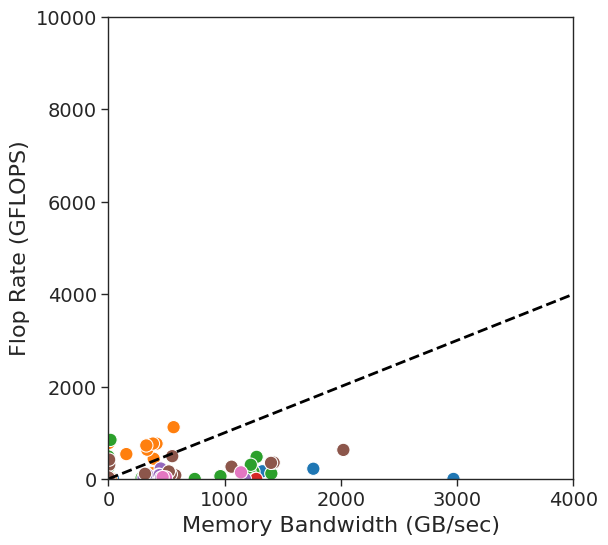

<Figure size 800x200 with 0 Axes>

In [55]:
# DDR Plot
fig_mem_v_flop_ddr, ax_mem_v_flop_ddr = plt.subplots(figsize=(6, 6))
sns.scatterplot(
    x=mem_v_flop_df[ddr_mem_bw_mean],
    y=mem_v_flop_df[ddr_flop_rate_mean],
    hue=mem_v_flop_df[("groups", "")],
    ax=ax_mem_v_flop_ddr,
    # kind="scatter",
    s=4 * mpl.rcParams['lines.markersize'] ** 2,
)
ax_mem_v_flop_ddr.set_xlim(left=0, right=4000)
ax_mem_v_flop_ddr.set_ylim(bottom=0, top=10000)
ax_mem_v_flop_ddr.set_xticks([0, 1000, 2000, 3000, 4000], [0, 1000, 2000, 3000, 4000])
ax_mem_v_flop_ddr.set_xlabel("Memory Bandwidth (GB/sec)", fontsize=16)
ax_mem_v_flop_ddr.set_ylabel("Flop Rate (GFLOPS)", fontsize=16)
ax_mem_v_flop_ddr.tick_params(axis="both", which="major", labelsize=14)
plot_straight_line(ax_mem_v_flop_ddr, [0, 0], [mem_v_flop_df[ddr_mem_bw_mean].max(), mem_v_flop_df[ddr_mem_bw_mean].max()], c="k", linestyle="--", linewidth=2)
# ax_mem_v_flop_ddr.plot([0, mem_v_flop_df[ddr_mem_bw_mean].max()], [0, mem_v_flop_df[ddr_mem_bw_mean].max()], "k--", linewidth=2)
sns.move_legend(ax_mem_v_flop_ddr, "center", title="Category")

mem_v_flop_figlegend = plt.figure(figsize=(8,2))
mem_v_flop_patches, mem_v_flop_labels = ax_mem_v_flop_ddr.get_legend_handles_labels()
mem_v_flop_figlegend.legend(mem_v_flop_patches, mem_v_flop_labels, title="Kernel Group", ncols=7, fontsize=18, title_fontsize=18)
ax_mem_v_flop_ddr.get_legend().remove()
#fig_mem_v_flop_ddr.savefig("figures/mem_bw_v_flops_ddr.png", bbox_inches="tight", dpi=200)

In [56]:
#mem_v_flop_figlegend.savefig("figures/mem_v_flop_legend.png", bbox_inches="tight", dpi=200)

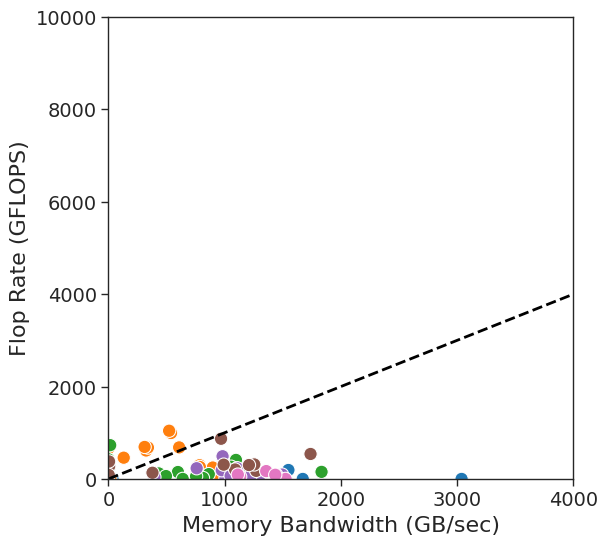

In [57]:
# HBM Plot
fig_mem_v_flop_hbm, ax_mem_v_flop_hbm = plt.subplots(figsize=(6, 6))
sns.scatterplot(
    x=mem_v_flop_df[hbm_mem_bw_mean],
    y=mem_v_flop_df[hbm_flop_rate_mean],
    hue=mem_v_flop_df[("groups", "")],
    ax=ax_mem_v_flop_hbm,
    # kind="scatter",
    s=4 * mpl.rcParams['lines.markersize'] ** 2,
)
ax_mem_v_flop_hbm.set_xlim(left=0, right=4000)
ax_mem_v_flop_hbm.set_ylim(bottom=0, top=10000)
ax_mem_v_flop_hbm.set_xticks([0, 1000, 2000, 3000, 4000], [0, 1000, 2000, 3000, 4000])
ax_mem_v_flop_hbm.set_xlabel("Memory Bandwidth (GB/sec)", fontsize=16)
ax_mem_v_flop_hbm.set_ylabel("Flop Rate (GFLOPS)", fontsize=16)
ax_mem_v_flop_hbm.tick_params(axis="both", which="major", labelsize=14)
plot_straight_line(ax_mem_v_flop_hbm, [0, 0], [mem_v_flop_df[hbm_mem_bw_mean].max(), mem_v_flop_df[hbm_mem_bw_mean].max()], c="k", linestyle="--", linewidth=2)
# ax_mem_v_flop_hbm.plot([0, mem_v_flop_df[hbm_mem_bw_mean].max()], [0, mem_v_flop_df[hbm_mem_bw_mean].max()], "k--", linewidth=2)
ax_mem_v_flop_hbm.get_legend().remove()
#fig_mem_v_flop_hbm.savefig("figures/mem_bw_v_flops_hbm.png", bbox_inches="tight")

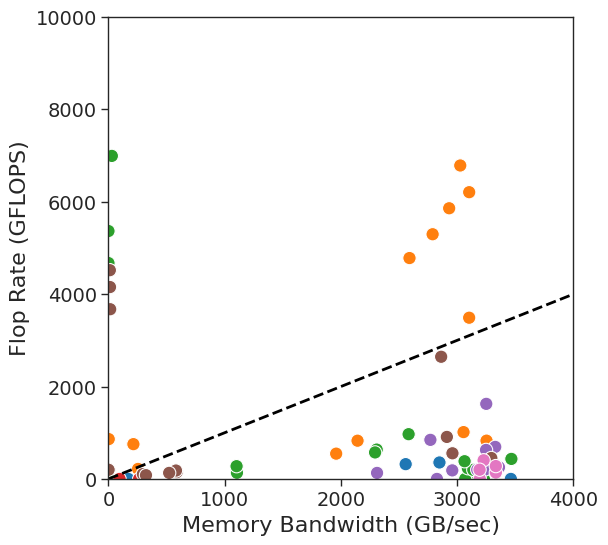

In [58]:
# V100 Plot
fig_mem_v_flop_v100, ax_mem_v_flop_v100 = plt.subplots(figsize=(6, 6))
sns.scatterplot(
    x=mem_v_flop_df[v100_mem_bw_mean],
    y=mem_v_flop_df[v100_flop_rate_mean],
    hue=mem_v_flop_df[("groups", "")],
    ax=ax_mem_v_flop_v100,
    # kind="scatter",
    s=4 * mpl.rcParams['lines.markersize'] ** 2,
)
ax_mem_v_flop_v100.set_xlim(left=0, right=4000)
ax_mem_v_flop_v100.set_ylim(bottom=0, top=10000)
ax_mem_v_flop_v100.set_xticks([0, 1000, 2000, 3000, 4000], [0, 1000, 2000, 3000, 4000])
ax_mem_v_flop_v100.set_xlabel("Memory Bandwidth (GB/sec)", fontsize=16)
ax_mem_v_flop_v100.set_ylabel("Flop Rate (GFLOPS)", fontsize=16)
ax_mem_v_flop_v100.tick_params(axis="both", which="major", labelsize=14)
plot_straight_line(ax_mem_v_flop_v100, [0, 0], [mem_v_flop_df[v100_mem_bw_mean].max(), mem_v_flop_df[v100_mem_bw_mean].max()], c="k", linestyle="--", linewidth=2)
# ax_mem_v_flop_v100.plot([0, mem_v_flop_df[v100_mem_bw_mean].max()], [0, mem_v_flop_df[v100_mem_bw_mean].max()], "k--", linewidth=2)
ax_mem_v_flop_v100.get_legend().remove()
#fig_mem_v_flop_v100.savefig("figures/mem_bw_v_flops_v100.png", bbox_inches="tight", dpi=200)

[78.08415154702564, 232.7303250881792, 5027.180709278552, 7884.638183530316]
[13326.385238341536, 84113.33073775537, 11259.015340240285, 14974.466514869282]
['Basic_MAT_MAT_SHARED', 'Apps_EDGE3D', 'Apps_VOL3D', 'Apps_DIFFUSION3DPA']


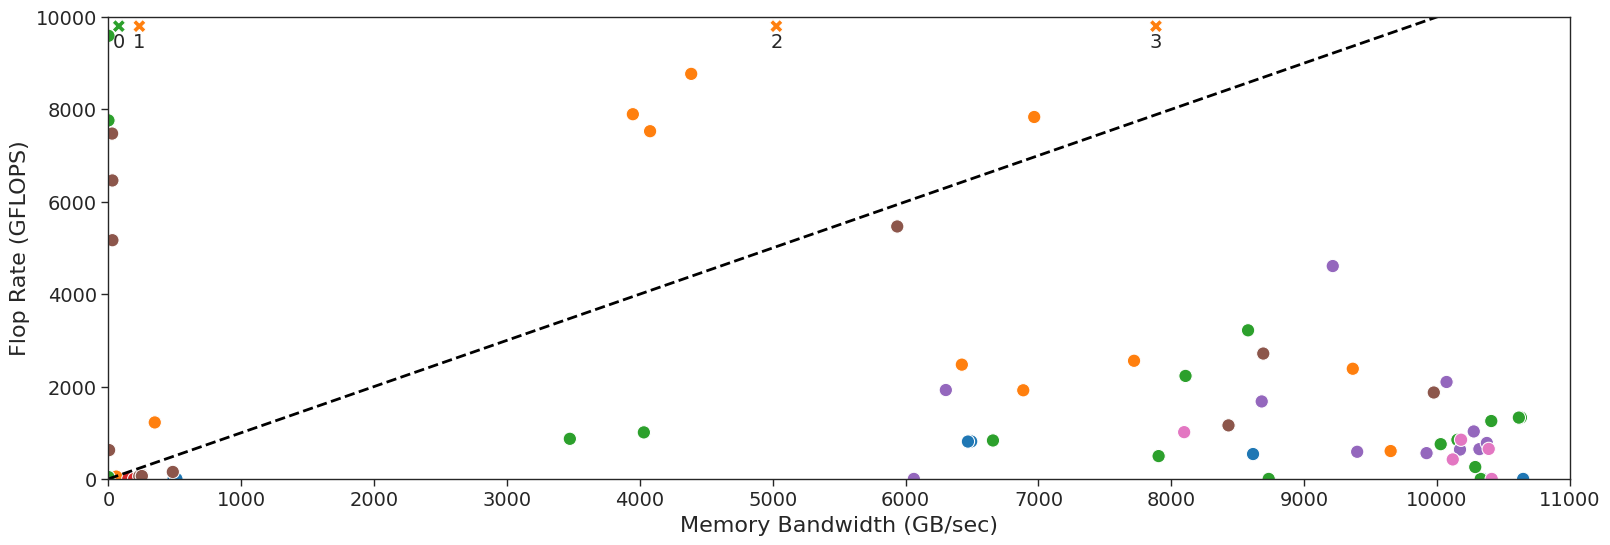

In [59]:
# MI250X Plot
fig_mem_v_flop_mi250x, ax_mem_v_flop_mi250x = plt.subplots(figsize=(6*(11000 / 3500), 6))

mi250x_ylim = 10000
mi250x_ylim_pad = 200

new_mi250x_x = mem_v_flop_df[mi250x_mem_bw_mean].tolist()
new_mi250x_y = mem_v_flop_df[mi250x_flop_rate_mean].tolist()
label_mi250x_markers = [0 for _ in range(len(new_mi250x_x))]
labels_mi250x = []
for i in range(len(new_mi250x_x)):
    y = new_mi250x_y[i]
    if y > mi250x_ylim:
        labels_mi250x.append((new_mi250x_x[i], new_mi250x_y[i], i))
        new_mi250x_y[i] = mi250x_ylim - mi250x_ylim_pad
        label_mi250x_markers[i] = 1
        
labels_mi250x = list(sorted(labels_mi250x, key=lambda tup: tup[0]))
label_mi250x_x = [tup[0] for tup in labels_mi250x]
label_mi250x_y = [tup[1] for tup in labels_mi250x]
label_mi250x_names = [tup[2] for tup in labels_mi250x]
        
label_mi250x_names = [mem_v_flop_df[("name", "")].iloc[i] for i in label_mi250x_names]
print(label_mi250x_x)
print(label_mi250x_y)
print(label_mi250x_names)

sns.scatterplot(
    x=np.array(new_mi250x_x),  # mem_v_flop_df[mi250x_mem_bw_mean],
    y=np.array(new_mi250x_y),  # mem_v_flop_df[mi250x_flop_rate_mean],
    hue=mem_v_flop_df[("groups", "")],
    style=label_mi250x_markers,
    ax=ax_mem_v_flop_mi250x,
    # kind="scatter",
    s=4 * mpl.rcParams['lines.markersize'] ** 2,
)
ax_mem_v_flop_mi250x.set_xlim(left=0, right=11000)
ax_mem_v_flop_mi250x.set_ylim(bottom=0, top=mi250x_ylim) # 90000
ax_mem_v_flop_mi250x.set_xticks(list(range(0, 11001, 1000)), list(range(0, 11001, 1000)))
ax_mem_v_flop_mi250x.set_xlabel("Memory Bandwidth (GB/sec)", fontsize=16)
ax_mem_v_flop_mi250x.set_ylabel("Flop Rate (GFLOPS)", fontsize=16)
ax_mem_v_flop_mi250x.tick_params(axis="both", which="major", labelsize=14)
plot_straight_line(ax_mem_v_flop_mi250x, [0, 0], [mem_v_flop_df[mi250x_mem_bw_mean].max(), mem_v_flop_df[mi250x_mem_bw_mean].max()], c="k", linestyle="--", linewidth=2)
# ax_mem_v_flop_mi250x.plot([0, mem_v_flop_df[mi250x_mem_bw_mean].max()], [0, mem_v_flop_df[mi250x_mem_bw_mean].max()], "k--", linewidth=2)

for i in range(len(label_mi250x_x)):
    label_pt = (label_mi250x_x[i], mi250x_ylim - 2.75*mi250x_ylim_pad)
    ax_mem_v_flop_mi250x.annotate(
        "{}".format(i),
        xy=label_pt,
        xytext=(0,0),
        fontsize=14,
        textcoords='offset points',
        ha="center",
        va="center",
    )

ax_mem_v_flop_mi250x.get_legend().remove()
#fig_mem_v_flop_mi250x.savefig("figures/mem_bw_v_flops_mi250x.png", bbox_inches="tight", dpi=200)

## Plot Bytes Read/Rep, Bytes Written per Rep, FLOPs per Rep, and FLOPs per Byte

In [60]:
analytic_metric_color_map = sns.color_palette("colorblind")

In [61]:
analytic_met_read_df = th.statsframe.dataframe[[
    ("name", ""),
    ddr_bytes_read_per_rep_scaled_mean,
    ddr_flops_per_rep_scaled_mean,
    ddr_flops_per_byte_mean,
]]
analytic_met_write_df = th.statsframe.dataframe[[
    ("name", ""),
    ddr_bytes_write_per_rep_scaled_mean,
    ddr_flops_per_rep_scaled_mean,
    ddr_flops_per_byte_mean,
]]
analytic_met_read_df.columns = analytic_met_read_df.columns.to_flat_index()
analytic_met_read_df.rename(
    columns={
        ("name", ""): "Kernel",
        ddr_bytes_read_per_rep_scaled_mean: "BytesR/W",
        ddr_flops_per_rep_scaled_mean: "FLOPs",
        ddr_flops_per_byte_mean: "FLOPs/Byte",
    },
    inplace=True
)
analytic_met_read_df["FLOPs/Byte"] = analytic_met_read_df["FLOPs/Byte"].apply(lambda x: x if x < 1000 else 0.0)
analytic_met_write_df.columns = analytic_met_write_df.columns.to_flat_index()
analytic_met_write_df.rename(
    columns={
        ("name", ""): "Kernel",
        ddr_bytes_write_per_rep_scaled_mean: "BytesR/W",
        ddr_flops_per_rep_scaled_mean: "FLOPs",
        ddr_flops_per_byte_mean: "FLOPs/Byte",
    },
    inplace=True
)
analytic_met_read_df["type"] = "Read"
analytic_met_write_df["type"] = "Write"
analytic_met_df = pd.concat([analytic_met_read_df, analytic_met_write_df]).reset_index(drop=True)

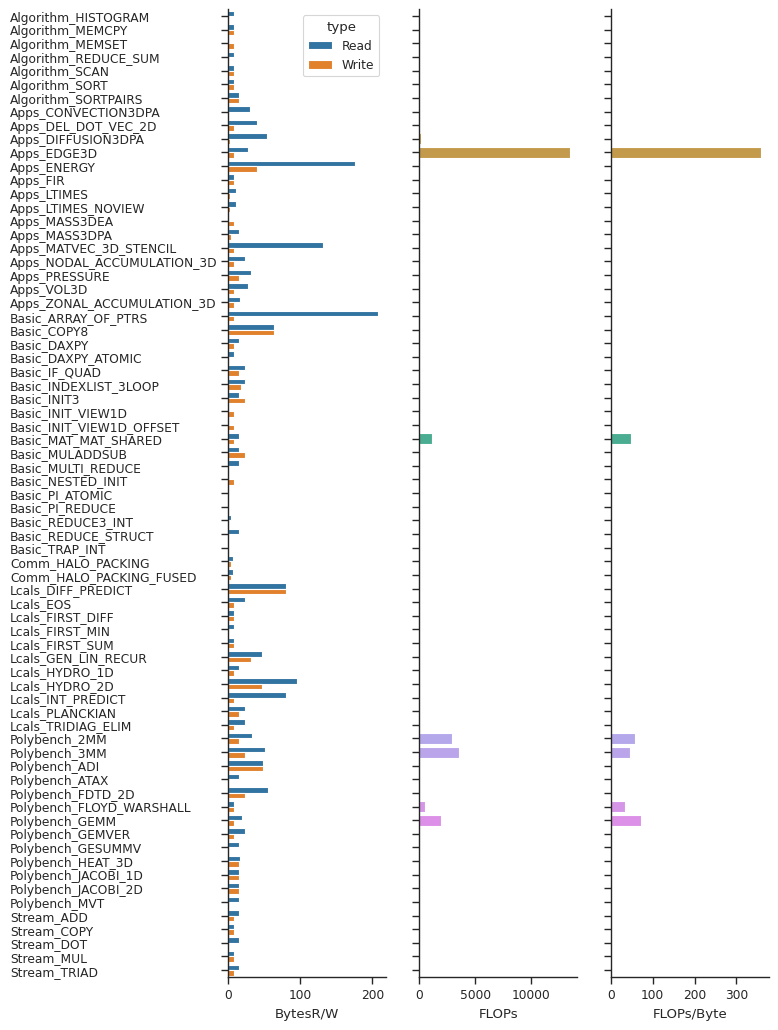

In [62]:
pg_analytic = sns.PairGrid(
    data=analytic_met_read_df,
    y_vars=["Kernel"],
    x_vars=["BytesR/W", "FLOPs", "FLOPs/Byte"],
    despine=True,
    height=10.5,
    aspect=0.2
)
pg_analytic.tight_layout()
pg_analytic.map(sns.barplot)

pg_analytic.figure.axes[0].clear()
sns.barplot(
    data=analytic_met_df,
    y="Kernel",
    x="BytesR/W",
    hue="type",
    ax=pg_analytic.figure.axes[0],
)
pg_analytic.figure.axes[0].get_yaxis().get_label().set_visible(False)

pg_analytic_y_ax = pg_analytic.figure.axes[0].get_yaxis()
pg_analytic_y_ax.set_tick_params(pad=152)
for tick in pg_analytic_y_ax.get_majorticklabels():
    tick.set_horizontalalignment("left")

## Plot DDR Top-Down

In [63]:
ddr_tma_df = th.statsframe.dataframe[[
    ("name", ""),
    # ddr_mem_bw_mean,
    # ddr_flop_rate_mean,
    ddr_fe_bound_mean,
    ddr_bad_spec_mean,
    ddr_retiring_mean,
    ddr_core_bound_mean,
    ddr_mem_bound_mean
]]
ddr_tma_df.columns = ddr_tma_df.columns.to_flat_index()
ddr_tma_df.rename(
    columns={
        ("name", ""): "Kernel",
        # ddr_mem_bw_mean: "Memory Bandwidth (GiB/s)",
        # ddr_flop_rate_mean: "FLOP Rate (GiFLOPS/s)",
        ddr_fe_bound_mean: "Frontend Bound",
        ddr_bad_spec_mean: "Bad Speculation",
        ddr_retiring_mean: "Retiring",
        ddr_core_bound_mean: "Core Bound",
        ddr_mem_bound_mean: "Memory Bound",
    },
    inplace=True
)

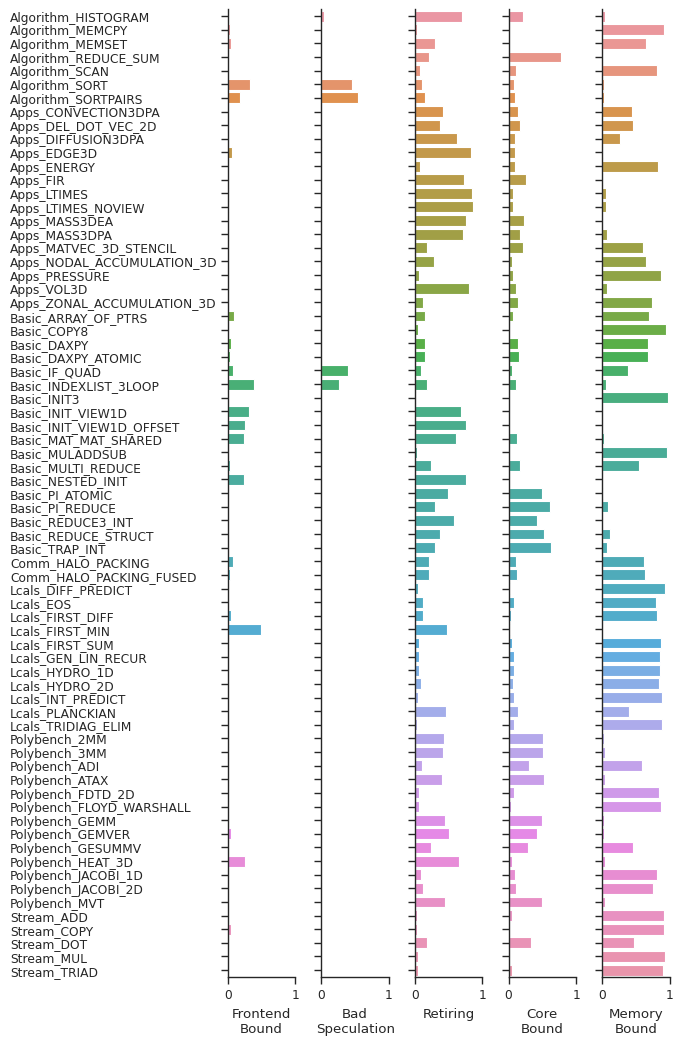

In [64]:
pg_ddr_tma = sns.PairGrid(
    data=ddr_tma_df,
    y_vars=["Kernel"],
    x_vars=[
        # "Memory Bandwidth (GiB/s)",
        # "FLOP Rate (GiFLOPS/s)",
        "Frontend Bound",
        "Bad Speculation",
        "Retiring",
        "Core Bound",
        "Memory Bound"
    ],
    despine=True,
    height=10.5,
    aspect=0.1
)
pg_ddr_tma.tight_layout()
pg_ddr_tma.map(sns.barplot)
pg_ddr_tma.figure.axes[0].get_yaxis().get_label().set_visible(False)
for ax in pg_ddr_tma.figure.axes:
    ax.set_xlim(0, 1)
    ax.set_xlabel(ax.get_xlabel().replace(" ", "\n"))
pg_ddr_tma_y_ax = pg_ddr_tma.figure.axes[0].get_yaxis()
pg_ddr_tma_y_ax.set_tick_params(pad=152)
for tick in pg_ddr_tma_y_ax.get_majorticklabels():
    tick.set_horizontalalignment("left")
#pg_ddr_tma.figure.savefig("figures/ddr_topdown_per_kernel.png", bbox_inches="tight", dpi=200)

## Plot HBM Top-Down

In [65]:
hbm_tma_df = th.statsframe.dataframe[[
    ("name", ""),
    # hbm_mem_bw_mean,
    # hbm_flop_rate_mean,
    hbm_fe_bound_mean,
    hbm_bad_spec_mean,
    hbm_retiring_mean,
    hbm_core_bound_mean,
    hbm_mem_bound_mean
]]
hbm_tma_df.columns = hbm_tma_df.columns.to_flat_index()
hbm_tma_df.rename(
    columns={
        ("name", ""): "Kernel",
        # hbm_mem_bw_mean: "Memory Bandwidth (GiB/s)",
        # hbm_flop_rate_mean: "FLOP Rate (GiFLOPS/s)",
        hbm_fe_bound_mean: "Frontend Bound",
        hbm_bad_spec_mean: "Bad Speculation",
        hbm_retiring_mean: "Retiring",
        hbm_core_bound_mean: "Core Bound",
        hbm_mem_bound_mean: "Memory Bound",
    },
    inplace=True
)

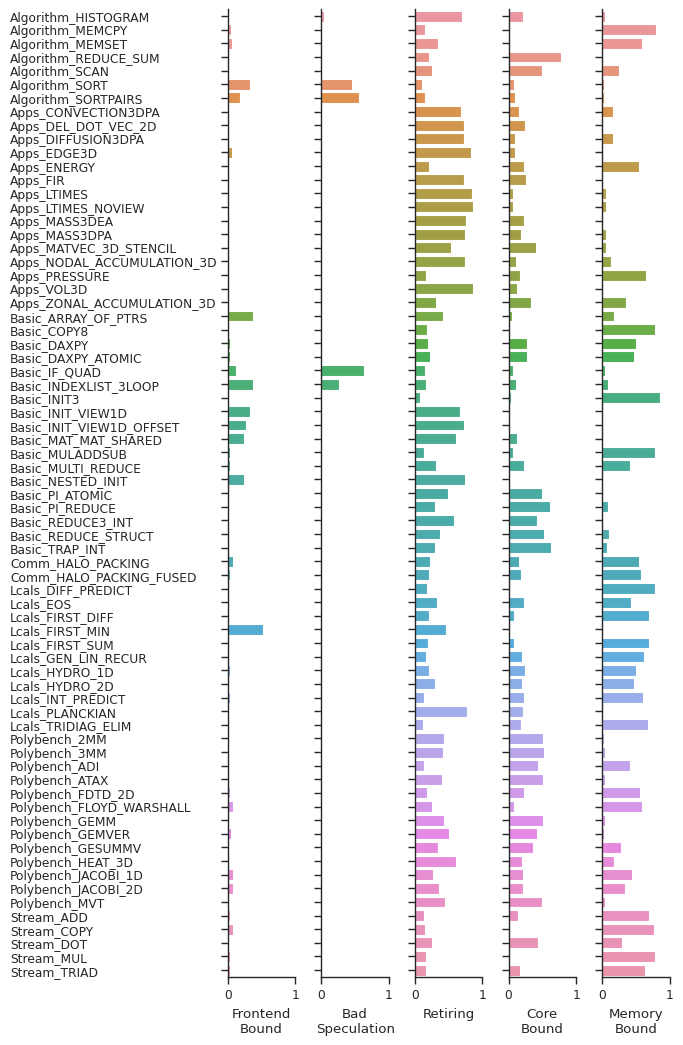

In [66]:
pg_hbm_tma = sns.PairGrid(
    data=hbm_tma_df,
    y_vars=["Kernel"],
    x_vars=[
        # "Memory Bandwidth (GiB/s)",
        # "FLOP Rate (GiFLOPS/s)",
        "Frontend Bound",
        "Bad Speculation",
        "Retiring",
        "Core Bound",
        "Memory Bound"
    ],
    despine=True,
    height=10.5,
    aspect=0.1
)
pg_hbm_tma.tight_layout()
pg_hbm_tma.map(sns.barplot)
pg_hbm_tma.figure.axes[0].get_yaxis().get_label().set_visible(False)
for ax in pg_hbm_tma.figure.axes:
    ax.set_xlim(0, 1)
    ax.set_xlabel(ax.get_xlabel().replace(" ", "\n"))
pg_hbm_tma_y_ax = pg_hbm_tma.figure.axes[0].get_yaxis()
pg_hbm_tma_y_ax.set_tick_params(pad=152)
for tick in pg_hbm_tma_y_ax.get_majorticklabels():
    tick.set_horizontalalignment("left")
#pg_hbm_tma.figure.savefig("figures/hbm_topdown_per_kernel.png", bbox_inches="tight", dpi=200)

## Plot Speedup, DDR Memory Bound, and HBM Memory Bound

In [67]:
triple_plot_df = th.statsframe.dataframe[[("name", ""), ddr_mem_bound_mean, ddr_to_hbm_speedup, ddr_to_v100_speedup, ddr_to_mi250x_speedup]].reset_index(drop=True)
triple_plot_df.reset_index(inplace=True)
triple_plot_df

,index,name,ddr_topdown,hbm,v100,mi250x
,,,Memory bound_mean,speedup,speedup,speedup
0,0,Algorithm_HISTOGRAM,0.049784,0.878386,1.448340,3.684487
1,1,Algorithm_MEMCPY,0.922720,3.386796,6.473918,21.017597
2,2,Algorithm_MEMSET,0.646944,1.023321,1.166566,3.588471
3,3,Algorithm_REDUCE_SUM,0.007449,0.863619,2.139605,4.882868
4,4,Algorithm_SCAN,0.811522,2.927147,6.201060,17.215451
...,...,...,...,...,...,...
66,66,Stream_ADD,0.915294,2.362050,6.953190,21.112355
67,67,Stream_COPY,0.909846,3.074465,6.459098,21.052661
68,68,Stream_DOT,0.473905,1.188229,2.831148,7.101520


In [68]:
triple_plot_df.columns = triple_plot_df.columns.to_flat_index()
triple_plot_df.rename(
    columns={
        ("name", ""): "Kernel",
        ddr_mem_bound_mean: "DDR Memory Bound",
        ddr_to_hbm_speedup: "SPR-HBM Speedup",
        ddr_to_v100_speedup: "V100 Speedup",
        ddr_to_mi250x_speedup: "MI250X Speedup",
    },
    inplace=True
)

In [69]:
ddr_stream_copy_mem_bound = triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["DDR Memory Bound"].iloc[0]
hbm_stream_copy_spdup = triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["SPR-HBM Speedup"].iloc[0]
v100_stream_copy_spdup = triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["V100 Speedup"].iloc[0]
mi250x_stream_copy_spdup = triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["MI250X Speedup"].iloc[0]

In [70]:
th.statsframe.dataframe[ddr_to_mi250x_speedup].max()

118.59722036992399

In [71]:
#sns.set_palette("colorblind")
sns.set(palette="tab10", font_scale=0.8)
sns.set_style("ticks")

In [72]:
triple_plot_df["color"] = 1

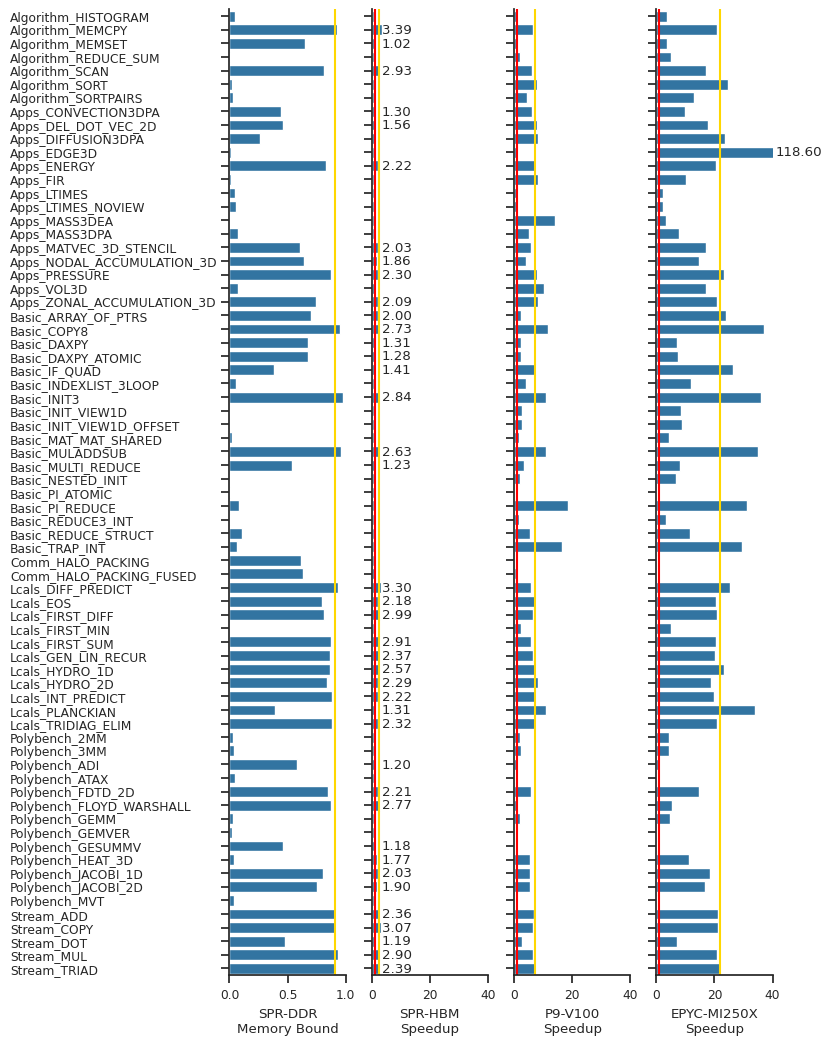

In [73]:
pg_triple = sns.PairGrid(
    data=triple_plot_df,
    y_vars=["Kernel"],
    x_vars=["DDR Memory Bound", "SPR-HBM Speedup", "V100 Speedup", "MI250X Speedup"],
    despine=True,
    height=10.5,
    aspect=0.15,
    hue="color"
)
pg_triple.tight_layout()
pg_triple.map(sns.barplot)
pg_triple.figure.axes[0].set_xlim(0, 1)
pg_triple.figure.axes[0].set_xlabel("SPR-DDR\nMemory Bound")
pg_triple.figure.axes[0].get_yaxis().get_label().set_visible(False)
pg_triple.figure.axes[0].axvline(ddr_stream_copy_mem_bound, color="gold")
pg_triple.figure.axes[1].axvline(1.0, color="red")
pg_triple.figure.axes[1].axvline(hbm_stream_copy_spdup, color="gold")
pg_triple.figure.axes[1].set_xlim(0, 40)
pg_triple.figure.axes[1].set_xlabel("SPR-HBM\nSpeedup")
pg_triple.figure.axes[2].axvline(1.0, color="red")
pg_triple.figure.axes[2].axvline(v100_stream_copy_spdup, color="gold")
pg_triple.figure.axes[2].set_xlim(0, 40)
pg_triple.figure.axes[2].set_xlabel("P9-V100\nSpeedup")
pg_triple.figure.axes[3].axvline(1.0, color="red")
pg_triple.figure.axes[3].axvline(mi250x_stream_copy_spdup, color="gold")
pg_triple.figure.axes[3].set_xlim(0, 40)
pg_triple.figure.axes[3].set_xlabel("EPYC-MI250X\nSpeedup")

gpu_stream_copy_spdups = {
    "V100": v100_stream_copy_spdup,
    "MI250X": mi250x_stream_copy_spdup,
}

starting_subplot_idx = 2

# for i, gpu_type in enumerate(["V100", "MI250X"]):
#     for label in pg_triple.figure.axes[0].get_yticklabels():
#         _, label_y = label.get_position()
#         if np.isnan(triple_plot_df[triple_plot_df["Kernel"] == label.get_text()]["{} Speedup".format(gpu_type)].iloc[0]):
#             pg_triple.figure.axes[starting_subplot_idx+i].annotate(
#                 "N/A",
#                 xy=(gpu_stream_copy_spdups[gpu_type], label_y),
#                 xytext=(2, 0),
#                 textcoords='offset points',
#                 ha="left",
#                 va="center",
#             )
            
for i, gpu_type in enumerate(["V100", "MI250X"]):
    for label in pg_triple.figure.axes[0].get_yticklabels():
        _, label_y = label.get_position()
        min_x, max_x = pg_triple.figure.axes[starting_subplot_idx+i].get_xlim()
        curr_kernel_speedup = triple_plot_df[triple_plot_df["Kernel"] == label.get_text()]["{} Speedup".format(gpu_type)].iloc[0]
        if curr_kernel_speedup > max_x:
            pg_triple.figure.axes[starting_subplot_idx+i].annotate(
                "{:.2f}".format(curr_kernel_speedup),
                xy=(max_x, label_y),
                xytext=(2, 0),
                textcoords='offset points',
                ha="left",
                va="center",
            )
starting_subplot_idx = 0         
for label in pg_triple.figure.axes[0].get_yticklabels():
    _, label_y = label.get_position()
    curr_kernel_speedup = triple_plot_df[triple_plot_df["Kernel"] == label.get_text()]["SPR-HBM Speedup"].iloc[0]
    if curr_kernel_speedup > 1:
        pg_triple.figure.axes[starting_subplot_idx+i].annotate(
            "{:.2f}".format(curr_kernel_speedup),
            xy=(2, label_y),
            xytext=(3, 0),
            textcoords='offset points',
            ha="left",
            va="center",
        )

pg_triple_y_ax = pg_triple.figure.axes[0].get_yaxis()
pg_triple_y_ax.set_tick_params(pad=152)
for tick in pg_triple_y_ax.get_majorticklabels():
    tick.set_horizontalalignment("left")

#pg_triple.figure.savefig("figures/ddr_mem_bound_and_speedup.png", bbox_inches="tight", dpi=200)

## Cluster Kernels with DDR Data (Agglomerative Clustering)

Set `clustering_metrics` to the metrics/column names you want to use in clustering

In [74]:
# Try bytes/rep, flops/rep, and flops/bytes (divide by problem size first)
clustering_metrics = [
    ddr_retiring_mean,
    # ddr_light_ops_mean,
    # ddr_heavy_ops_mean,
    ddr_fe_bound_mean,
    # ddr_fe_bw_mean,
    # ddr_fe_lat_mean,
    ddr_bad_spec_mean,
    ddr_core_bound_mean,
    ddr_mem_bound_mean,
    # ddr_bytes_read_per_rep_scaled_mean,
    # ddr_bytes_write_per_rep_scaled_mean,
    # ddr_flops_per_rep_scaled_mean,
    # ddr_flops_per_byte_mean,
    # ddr_read_bw_mean,
    # ddr_write_bw_mean,
    # ddr_flop_rate_mean,
]

In [75]:
# TODO: Did we filter out non O(n) kernels already?

# Non_On_kernels = ['Algorithm_SORT', 'Algorithm_SORTPAIRS', 'Comm_HALO_EXCHANGE', 'Comm_HALO_EXCHANGE_FUSED',
#                    'Comm_HALO_PACKING', 'Comm_HALO_PACKING_FUSED', 'Comm_HALO_SENDRECV', 'Polybench_2MM',
#                    'Polybench_3MM' , 'Polybench_FLOYD_WARSHALL', 'Polybench_GEMM', "Apps_EDGE3D", "Basic_PI_REDUCE"]

# filtered_th = th.statsframe.dataframe[~th.statsframe.dataframe['name'].isin(Non_On_kernels)]

In [77]:
#clustering_data = filtered_th.loc[:, clustering_metrics].copy(deep=True)
clustering_data = th.statsframe.dataframe.loc[:, clustering_metrics].copy(deep=True)
# scaler = MinMaxScaler() # StandardScaler()
# clustering_data = pd.DataFrame(scaler.fit_transform(clustering_data), columns=clustering_data.columns)

## Cluster with Aglomerative Clustering

In [79]:
thresh = 1.4
cluster_op = sk.AgglomerativeClustering(linkage="ward", distance_threshold=thresh, n_clusters=None, compute_full_tree=True)
th.statsframe.dataframe[("label", "")] = cluster_op.fit_predict(clustering_data)

# Plot Dendrogram

In [80]:
from scipy.cluster.hierarchy import dendrogram

def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    return dendrogram(linkage_matrix, **kwargs)

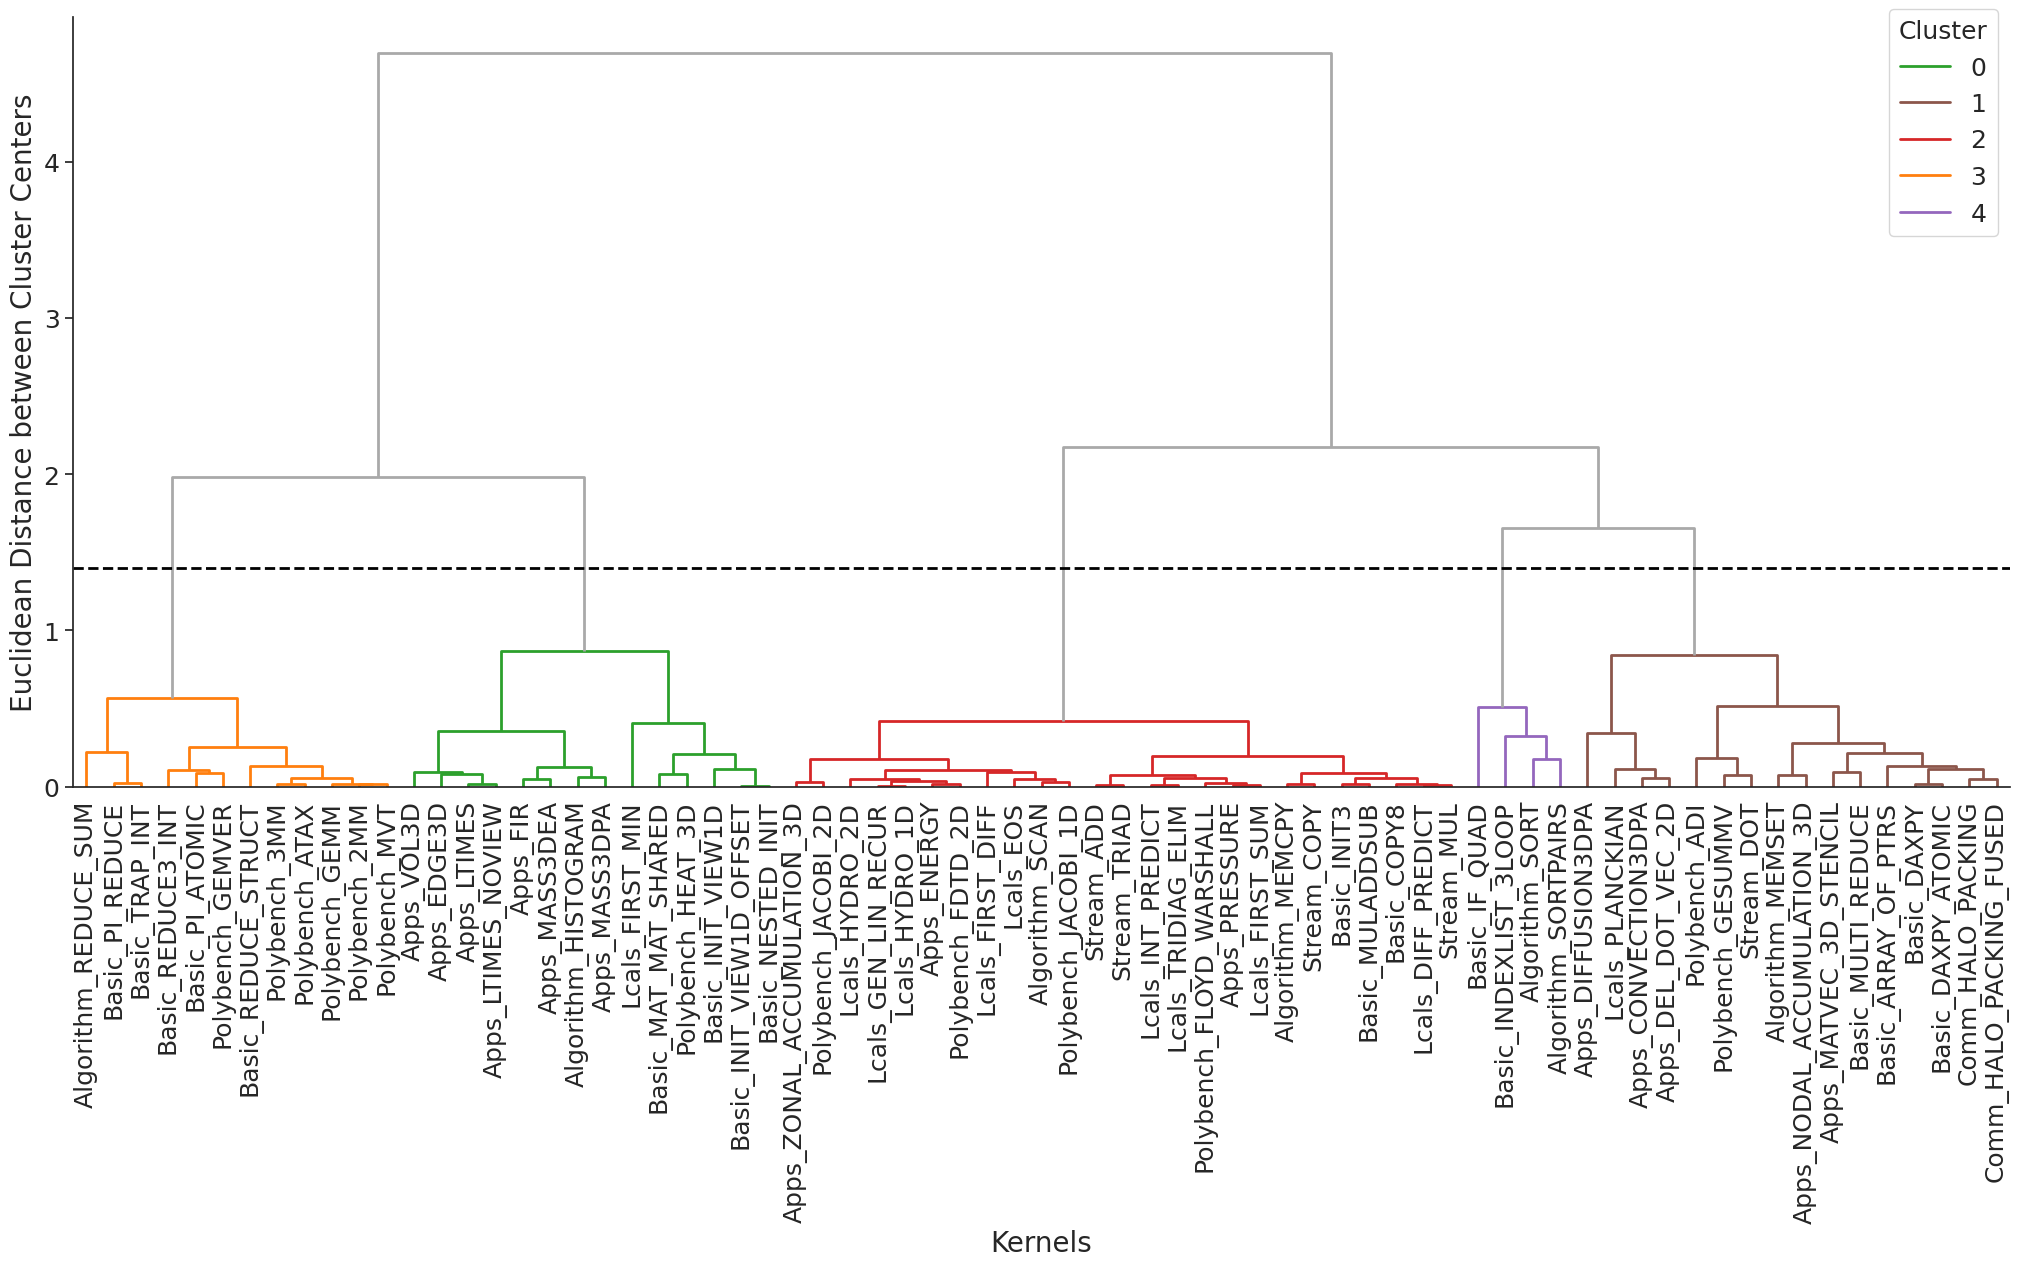

In [82]:
dendro_fig, dendro_ax = plt.subplots(figsize=(25, 10))

with plt.rc_context({'lines.linewidth': 2}):
    dendro_dict = plot_dendrogram(
        cluster_op,
        ax=dendro_ax,
        color_threshold=thresh,
        labels=th.statsframe.dataframe[("name", "")],
        above_threshold_color="darkgray",
        # orientation="right",
    )

    dendro_colors = {th.statsframe.dataframe[("label", "")].iloc[l]: c for l, c in zip(dendro_dict["leaves"], dendro_dict["leaves_color_list"])}
    dendro_labels = list(sorted([l for l in dendro_colors.keys()]))
    dendro_handles = []
    for label in dendro_labels:
        dendro_handles.append(plt.Line2D([0], [0], color=dendro_colors[label]))

    dendro_fig.legend(
        dendro_handles,
        dendro_labels,
        title="Cluster",
        loc="upper right",
        bbox_to_anchor=(0.9, 0.9),
        title_fontsize=18,
        fontsize=18,
    )
    dendro_ax.axhline(thresh, color="k", linestyle="--")

dendro_ax.spines[['right', 'top']].set_visible(False)
dendro_ax.set_ylabel("Euclidean Distance between Cluster Centers", fontsize=20)
dendro_ax.set_xlabel("Kernels", fontsize=20)
dendro_ax.tick_params(axis="both", which="major", labelsize=18)

#dendro_fig.savefig("figures/clustering_dendrogram.png", bbox_inches="tight", dpi=200)

## Summarize Clusters

In [83]:
cluster_summary_df = th.statsframe.dataframe[[("name", ""), *clustering_metrics, ddr_to_hbm_speedup, ddr_to_v100_speedup, ddr_to_mi250x_speedup, ("label", "")]].reset_index(drop=True)
cluster_summary_df.columns = cluster_summary_df.columns.to_flat_index()
cluster_summary_df.rename(
    columns={
        ("name", ""): "Kernel",
        ddr_fe_bound_mean: "Frontend Bound",
        ddr_bad_spec_mean: "Bad Speculation",
        ddr_retiring_mean: "Retiring",
        ddr_core_bound_mean: "Core Bound",
        ddr_mem_bound_mean: "Memory Bound",
        ddr_to_hbm_speedup: "Speedup on SPR-HBM",
        ddr_to_v100_speedup: "Speedup on P9-V100",
        ddr_to_mi250x_speedup: "Speedup on EPYC-MI250X",
        ("label", ""): "Cluster ID",
    },
    inplace=True
)
cluster_summary_df

,Kernel,Retiring,Frontend Bound,Bad Speculation,Core Bound,Memory Bound,Speedup on SPR-HBM,Speedup on P9-V100,Speedup on EPYC-MI250X,Cluster ID
0,Algorithm_HISTOGRAM,0.690707,0.010253,0.035223,0.214034,0.049784,0.878386,1.448340,3.684487,0
1,Algorithm_MEMCPY,0.034130,0.036830,0.000045,0.006275,0.922720,3.386796,6.473918,21.017597,2
2,Algorithm_MEMSET,0.299764,0.052811,0.000090,0.000392,0.646944,1.023321,1.166566,3.588471,1
3,Algorithm_REDUCE_SUM,0.208152,0.003664,0.000258,0.780477,0.007449,0.863619,2.139605,4.882868,3
4,Algorithm_SCAN,0.067790,0.007750,0.000087,0.112851,0.811522,2.927147,6.201060,17.215451,2
...,...,...,...,...,...,...,...,...,...,...
66,Stream_ADD,0.035294,0.004228,0.000086,0.045098,0.915294,2.362050,6.953190,21.112355,2
67,Stream_COPY,0.036062,0.047398,0.000034,0.006661,0.909846,3.074465,6.459098,21.052661,2
68,Stream_DOT,0.181774,0.007289,0.000165,0.336867,0.473905,1.188229,2.831148,7.101520,1
69,Stream_MUL,0.043580,0.009357,0.000064,0.012957,0.934042,2.902520,6.459979,21.022930,2


In [84]:
tma_metric_dfs = []
for m in ["Retiring", "Frontend Bound", "Bad Speculation", "Core Bound", "Memory Bound"]:
    single_tma_metric_df = cluster_summary_df[["Kernel", m, "Cluster ID"]]
    single_tma_metric_df.rename(columns={m: "TMA Metric"}, inplace=True)
    single_tma_metric_df["type"] = m
    tma_metric_dfs.append(single_tma_metric_df)

clustering_plotting_metric_df = pd.concat(tma_metric_dfs)

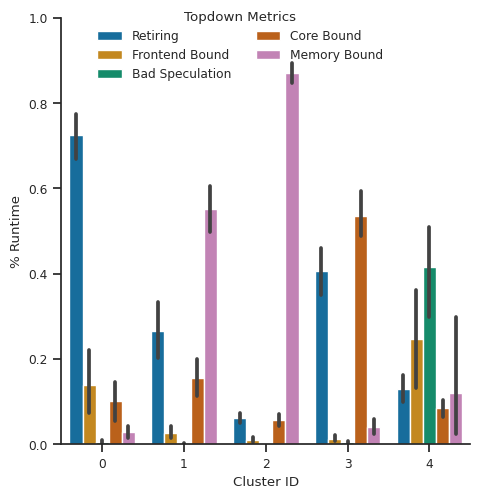

In [85]:
fg_cluster_summary = sns.catplot(
    data=clustering_plotting_metric_df,
    x="Cluster ID",
    y="TMA Metric",
    hue="type",
    kind="bar",
    palette="colorblind",
)
fg_cluster_summary.ax.set_ylabel("% Runtime")
# fg_cluster_summary.legend.set_title("Topdown Metrics")
# fg_cluster_summary.legend.set_ncols(5)
fg_cluster_summary.ax.set_ylim(bottom=0, top=1)
sns.move_legend(fg_cluster_summary, "upper center", title="Topdown Metrics", ncols=2)

# Parallel Coordinate Plots

In [86]:
import plotly.express as px
import pandas as pd
import os

import plotly.graph_objects as go

if not os.path.exists("images"):
    os.mkdir("images")

In [87]:
# Grab just the relevant metrics from above
# TODO: make sure only O(n) here
relevant_metrics_df = th.statsframe.dataframe[[
    ("name", ""),
    ddr_bytes_read_per_rep_scaled_mean,
    ddr_bytes_write_per_rep_scaled_mean,
    ddr_flops_per_rep_scaled_mean,
    ddr_flops_per_byte_mean,
    ddr_no_topdown_time_metric_mean,
    hbm_no_topdown_time_metric_mean,
    v100_time_metric_mean,
    mi250x_time_metric_mean,
    ddr_mem_bw_mean,
    ddr_flop_rate_mean,
    hbm_mem_bw_mean,
    hbm_flop_rate_mean,
    v100_mem_bw_mean,
    v100_flop_rate_mean,
    mi250x_mem_bw_mean,
    mi250x_flop_rate_mean,
    ddr_fe_bound_mean,
    ddr_bad_spec_mean,
    ddr_retiring_mean,
    ddr_core_bound_mean,
    ddr_mem_bound_mean,
    ddr_to_hbm_speedup,
    ddr_to_v100_speedup,
    ddr_to_mi250x_speedup,
    ("label", ""),
]].copy(deep=True)
relevant_metrics_df.columns = relevant_metrics_df.columns.to_flat_index()
relevant_metrics_df.rename(
    columns={
        ("name", ""): "Kernel",
        ddr_bytes_read_per_rep_scaled_mean: "BytesRead",
        ddr_bytes_write_per_rep_scaled_mean: "BytesWrite",
        ddr_flops_per_rep_scaled_mean: "FLOP",
        ddr_flops_per_byte_mean: "FLOP/Byte",
        ddr_no_topdown_time_metric_mean: "SPR-DDR Time",
        hbm_no_topdown_time_metric_mean: "SPR-HBM Time",
        v100_time_metric_mean: "P9-V100 Time",
        mi250x_time_metric_mean: "EPYC-MI250X Time",
        ddr_mem_bw_mean: "SPR-DDR Memory Bandwidth (GB/sec)",
        ddr_flop_rate_mean: "SPR-DDR Flop Rate (GFLOPS)",
        hbm_mem_bw_mean: "SPR-HBM Memory Bandwidth (GB/sec)",
        hbm_flop_rate_mean: "SPR-HBM Flop Rate (GFLOPS)",
        v100_mem_bw_mean: "P9-V100 Memory Bandwidth (GB/sec)",
        v100_flop_rate_mean: "P9-V100 Flop Rate (GFLOPS)",
        mi250x_mem_bw_mean: "EPYC-MI250X Memory Bandwidth (GB/sec)",
        mi250x_flop_rate_mean: "EPYC-MI250X Flop Rate (GFLOPS)",
        ddr_fe_bound_mean: "Frontend Bound",
        ddr_bad_spec_mean: "Bad Speculation",
        ddr_retiring_mean: "Retiring",
        ddr_core_bound_mean: "Core Bound",
        ddr_mem_bound_mean: "Memory Bound",
        ddr_to_hbm_speedup: "Speedup on SPR-HBM",
        ddr_to_v100_speedup: "Speedup on P9-V100",
        ddr_to_mi250x_speedup: "Speedup on EPYC-MI250X",
        ("label", ""): "Cluster ID",
    },
    inplace=True,
)
relevant_metrics_df.reset_index(inplace=True, drop=True)
relevant_metrics_df.sort_values(by="Kernel", inplace=True)
relevant_metrics_df

,Kernel,BytesRead,BytesWrite,FLOP,FLOP/Byte,SPR-DDR Time,SPR-HBM Time,P9-V100 Time,EPYC-MI250X Time,SPR-DDR Memory Bandwidth (GB/sec),...,EPYC-MI250X Flop Rate (GFLOPS),Frontend Bound,Bad Speculation,Retiring,Core Bound,Memory Bound,Speedup on SPR-HBM,Speedup on P9-V100,Speedup on EPYC-MI250X,Cluster ID
0,Algorithm_HISTOGRAM,8.000267,0.000267,1.0,0.124992,0.038085,0.043358,0.026296,0.010337,1762.295247,...,8.116977e+02,0.010253,0.035223,0.690707,0.214034,0.049784,0.878386,1.448340,3.684487,0
1,Algorithm_MEMCPY,8.000000,8.000000,0.0,0.000000,0.545455,0.161054,0.084254,0.025952,492.139527,...,3.429483e-312,0.036830,0.000045,0.034130,0.006275,0.922720,3.386796,6.473918,21.017597,2
2,Algorithm_MEMSET,0.000000,8.000000,0.0,0.000000,0.045232,0.044201,0.038773,0.012605,2967.769980,...,7.061081e-312,0.052811,0.000090,0.299764,0.000392,0.646944,1.023321,1.166566,3.588471,1
3,Algorithm_REDUCE_SUM,8.000027,0.000027,1.0,0.124999,0.050691,0.058696,0.023692,0.010381,1323.882004,...,8.086469e+02,0.003664,0.000258,0.208152,0.780477,0.007449,0.863619,2.139605,4.882868,3
4,Algorithm_SCAN,8.000000,8.000000,1.0,0.062500,0.536408,0.183253,0.086503,0.031159,500.440876,...,5.384469e+02,0.007750,0.000087,0.067790,0.112851,0.811522,2.927147,6.201060,17.215451,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,Stream_ADD,16.000000,8.000000,1.0,0.041667,8.401478,3.556858,1.208291,0.397941,479.267233,...,4.215999e+02,0.004228,0.000086,0.035294,0.045098,0.915294,2.362050,6.953190,21.112355,2
67,Stream_COPY,8.000000,8.000000,0.0,0.000000,9.770020,3.177795,1.512598,0.464075,494.566430,...,3.452135e-312,0.047398,0.000034,0.036062,0.006661,0.909846,3.074465,6.459098,21.052661,2
68,Stream_DOT,16.000027,0.000027,2.0,0.125000,4.709796,3.963712,1.663564,0.663210,1140.064224,...,1.012097e+03,0.007289,0.000165,0.181774,0.336867,0.473905,1.188229,2.831148,7.101520,1
69,Stream_MUL,8.000000,8.000000,1.0,0.062500,9.777439,3.368603,1.513540,0.465085,494.190950,...,6.493222e+02,0.009357,0.000064,0.043580,0.012957,0.934042,2.902520,6.459979,21.022930,2


In [88]:
# Load data 
# TODO - continue from data above instead?
# all_kernels = pd.read_csv("relevant_rajaperf_metrics.csv")
# columns = ['Kernel','Bad Speculation', 'Frontend Bound', 
#         'Core Bound', 'Memory Bound','Retiring', 'Speedup on SPR-HBM',
#        'Speedup on P9-V100', 'Speedup on EPYC-MI250X', 'Cluster ID']
# all_kernels_pp = all_kernels[columns]
# all_kernels_pp.info()

In [94]:
from scipy import stats
# Determine outliers based on speedup
z = np.abs(stats.zscore(relevant_metrics_df['Speedup on EPYC-MI250X']))
outlier_indices = np.where(z > 3)[0]
pd_no_outliers_amd = relevant_metrics_df.drop(outlier_indices)

z = np.abs(stats.zscore(relevant_metrics_df['Speedup on P9-V100']))
outlier_indices = np.where(z > 3)[0]
pd_no_outliers_v100 = relevant_metrics_df.drop(outlier_indices)

dif1 = np.setdiff1d(pd_no_outliers_amd["Kernel"], pd_no_outliers_v100["Kernel"])
dif2 = np.setdiff1d(pd_no_outliers_v100["Kernel"], pd_no_outliers_amd["Kernel"])

temp3 = np.concatenate((dif1, dif2))
print(list(temp3))

['Basic_PI_REDUCE', 'Apps_EDGE3D']


In [95]:
# Remove the outliers
all_kernels_no_outliers = relevant_metrics_df[~relevant_metrics_df['Kernel'].isin(["Apps_EDGE3D", "Basic_PI_REDUCE"])]

### Parallel Coordinate Plot For all kernels

In [99]:
fig = go.Figure(data=
    [
    go.Parcoords(
        line = dict(color = all_kernels_no_outliers['Cluster ID'], #showscale = True,
                   colorscale = [[0,'green'],[0.25, 'brown'],[0.5,'red'],[0.75, 'orange'],[1,'purple'],]),
        dimensions = list([
            dict(range = [0,5],
                 tickvals = [0,0.2,0.4,0.6,0.8,1],
                label = 'Bad Speculation', values = all_kernels_no_outliers['Bad Speculation']),
            dict(range = [0,5],
                 tickvals = [0,0.2,0.4,0.6,0.8,1],
                label = 'Frontend Bound', values = all_kernels_no_outliers['Frontend Bound']),
            dict(range = [0,5],
                 tickvals = [0,0.2,0.4,0.6,0.8,1],
                label = 'Core Bound', values = all_kernels_no_outliers['Core Bound']),
            dict(range = [0,5],
                 tickvals = [0,0.2,0.4,0.6,0.8,1],
                label = 'Memory Bound', values = all_kernels_no_outliers['Memory Bound']),
            dict(range = [0,5],
                 tickvals = [0,0.2,0.4,0.6,0.8,1],
                label = 'Retiring', values = all_kernels_no_outliers['Retiring']),
            dict(range = [-10,40],
                 tickvals = [0,5],
                label = 'SPR-HBM Speedup', values = all_kernels_no_outliers['Speedup on SPR-HBM']),
            dict(range = [-10,40],
                 tickvals = [0,5,10,15,20,],
                label = 'P9-V100 Speedup', values = all_kernels_no_outliers['Speedup on P9-V100']),
            dict(range = [-10,40],
                 tickvals = [0,10,20,30,40],
                label = 'EPYC-MI250X Speedup', values = all_kernels_no_outliers['Speedup on EPYC-MI250X'])
        ])
    #)
    ),
                    #Custom Legend
    go.Scatter(
            x=[None],
            y=[None],
            mode="lines",
            name="0",
            marker=dict(size=7, color="green", ),
        ),

        go.Scatter(
            x=[None],
            y=[None],
            mode="lines",
            name="1",
            marker=dict(size=7, color="brown", ),
        ),

        go.Scatter(
            x=[None],
            y=[None],
            mode="lines",
            name="2",
            marker=dict(size=7, color="red",),
        ),
        go.Scatter(
            x=[None],
            y=[None],
            mode="lines",
            name="3",
            marker=dict(size=7, color="orange",),
        ),

        go.Scatter(
            x=[None],
            y=[None],
            mode="lines",
            name="4",
            marker=dict(size=7, color="purple",),
        ),
                        
    ]   
)

fig.update_layout(
    width=900, height=1000,
    plot_bgcolor = 'white',
    paper_bgcolor = 'white'
)

fig.update_xaxes(showticklabels=False)
fig.update_yaxes(showticklabels=False)
fig.update_layout(legend=dict(
    title="Cluster",
    orientation="h",
    yanchor="auto",
    y=0.9,
    xanchor="right",  # changed
    x=0.4
    ))

#fig.write_image("images/par_coord_NO_OUTLIERS.png")

fig.show()

### Plot the average for each cluster

In [100]:
# Get the averages
avg_no_outliers = all_kernels_no_outliers.groupby('Cluster ID', as_index=False).mean()
avg_no_outliers.head()

TypeError: agg function failed [how->mean,dtype->object]

In [98]:
# fig = go.Figure(data=
#     [
#     go.Parcoords(
#         line = dict(color = avg_no_outliers['Cluster ID'], #showscale = True,
#                    colorscale = [[0,'green'],[0.25, 'brown'],[0.5,'red'],[0.75, 'orange'],[1,'purple'],]),
#         dimensions = list([
#             dict(range = [0,3],
#                  tickvals = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
#                 label = 'Bad Speculation', values = avg_no_outliers['Bad Speculation']),
#             dict(range = [0,3],
#                  tickvals = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
#                 label = 'Frontend Bound', values = avg_no_outliers['Frontend Bound']),
#             dict(range = [0,3],
#                  tickvals = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
#                 label = 'Core Bound', values = avg_no_outliers['Core Bound']),
#             dict(range = [0,3],
#                  tickvals = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
#                 label = 'Memory Bound', values = avg_no_outliers['Memory Bound']),
#             dict(range = [0,3],
#                  tickvals = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
#                 label = 'Retiring', values = avg_no_outliers['Retiring']),
#             dict(range = [-10,22],
#                  tickvals = [0,2,4,],
#                 label = 'SPR-HBM Speedup', values = avg_no_outliers['Speedup on SPR-HBM']),
#             dict(range = [-10,22],
#                  tickvals = [0,2,4,6,8,10],
#                 label = 'P9-V100 Speedup', values = avg_no_outliers['Speedup on P9-V100']),
#             dict(range = [-10,22],
#                  tickvals = [0,2,4,6,8,10,12,14,16,18,20,22],
#                 label = 'EPYC-MI250X Speedup', values = avg_no_outliers['Speedup on EPYC-MI250X'])
#         ])
# #    )
#     ),
#                     #Custom Legend
#     go.Scatter(
#             x=[None],
#             y=[None],
#             mode="lines",
#             name="0",
#             marker=dict(size=7, color="green", ),
#         ),

        go.Scatter(
            x=[None],
            y=[None],
            mode="lines",
            name="1",
            marker=dict(size=7, color="brown", ),
        ),

        go.Scatter(
            x=[None],
            y=[None],
            mode="lines",
            name="2",
            marker=dict(size=7, color="red",),
        ),
        go.Scatter(
            x=[None],
            y=[None],
            mode="lines",
            name="3",
            marker=dict(size=7, color="orange",),
        ),

        go.Scatter(
            x=[None],
            y=[None],
            mode="lines",
            name="4",
            marker=dict(size=7, color="purple",),
        ),
                        
    ]   
)

fig.update_layout(
    width=1100, height=750,
    plot_bgcolor = 'white',
    paper_bgcolor = 'white'
)
fig.update_xaxes(showticklabels=False)
fig.update_yaxes(showticklabels=False)
fig.update_layout(legend=dict(
    title="Cluster",
    orientation="h",
    yanchor="auto",
    y=0.9,
    xanchor="right",  # changed
    x=0.3
    ))

#fig.write_image("images/par_coord_AVG_NO_OUTLIERS.png")

fig.show()

NameError: name 'avg_no_outliers' is not defined